# Customer Risk Scoring — Final Notebook

**Dataset:** IBM TabFormer synthetic credit-card transaction dataset
(Kaggle: `ealtman2019/credit-card-transactions`; source:
[IBM/TabFormer](https://github.com/IBM/TabFormer)). Not the newer
commercial "IBM Synthetic Data Sets — Payment Cards" product — that
product isn't publicly downloadable, so this public IBM Research dataset
is used instead.

## The business problem

We are **not** answering "is this transaction fraudulent?" (that's
transaction-level fraud detection, a different, easier problem with a
near-instant feedback loop). We are answering:

> **"Given everything we know about this customer up to today, how
> likely are they to experience fraud in the future?"**

That's a forward-looking, customer-level underwriting/monitoring
question — the kind a risk team asks when deciding which accounts need
closer review, tighter limits, or proactive outreach, before fraud
happens rather than after.

## The pipeline, end to end

```
TRANSACTIONS (24.4M rows, 2,000 customers)
        ↓
CUSTOMER HISTORY  (everything on/before a cutoff date)
        ↓
CUSTOMER FEATURES  (profile + card + behavioral, all pre-cutoff)
        ↓
FUTURE RISK TARGET  (≥1 fraud transaction after cutoff, within a window)
        ↓
ML MODEL  (Dummy → Logistic Regression → Random Forest → XGBoost →
           LightGBM → CatBoost → FT-Transformer, all compared fairly)
        ↓
FRAUD PROBABILITY
        ↓
CALIBRATION  (so the probability is actually trustworthy, not just rank-ordered)
        ↓
0–100 CUSTOMER RISK SCORE
        ↓
RISK BAND  (Very Low / Low / Medium / High / Very High)
```

## What changed in this revision

This is a full rebuild following a line-by-line audit of a prior executed
run. Two consequential issues found in that audit are fixed here:

1. **A validation-leakage bug**, not a modeling weakness: the previous
   run used `sklearn.RandomizedSearchCV` with its default `refit=True`
   for Logistic Regression and Random Forest, which silently refits the
   winning model on **train+validation combined** — so the "validation"
   metrics reported for those two models were partly in-sample. This is
   why Random Forest looked implausibly strong on validation (ROC-AUC
   0.998) and then collapsed on the untouched test set (ROC-AUC 0.519,
   barely above random). **Every model in this notebook is now tuned and
   evaluated with a strict train-only refit** — no exceptions.
2. **Missing analysis**: no EDA visualizations, no confusion matrix, no
   ROC/PR curves, no calibration plot, no risk-score validation, and only
   a single customer shown in the demo. All added below.

Every number below comes from actually running this notebook — nothing
is pre-filled.

## 02. Environment & Reproducibility

In [1]:
import sys, platform, os, gc, time, json, warnings, random
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("=== Python / OS ===")
print("Python:", sys.version)
print("Platform:", platform.platform())
print()
print("=== Core library versions ===")
print("numpy:", np.__version__, " pandas:", pd.__version__, " scikit-learn:", sklearn.__version__)
import xgboost, lightgbm, catboost
print("xgboost:", xgboost.__version__, " lightgbm:", lightgbm.__version__, " catboost:", catboost.__version__)

import torch
torch.manual_seed(SEED)
print("torch:", torch.__version__)
GPU_AVAILABLE = torch.cuda.is_available()
print("CUDA available:", GPU_AVAILABLE)
if GPU_AVAILABLE:
    print("GPU name:", torch.cuda.get_device_name(0))
    torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda")
else:
    print("No GPU detected -- falling back to CPU.")
    device = torch.device("cpu")
print("Selected device for FT-Transformer:", device)
print(f"\nGlobal random seed: {SEED} (used for numpy, random, torch, and every model's random_state)")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

def mem_report(label):
    import psutil
    proc = psutil.Process(os.getpid())
    print(f"[MEMORY] {label}: process RSS = {proc.memory_info().rss / 1e9:.2f} GB")

try:
    import psutil
except ImportError:
    os.system("pip install -q psutil")
mem_report("after environment setup")

=== Python / OS ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35

=== Core library versions ===
numpy: 2.0.2  pandas: 2.3.3  scikit-learn: 1.6.1
xgboost: 3.2.0  lightgbm: 4.6.0  catboost: 1.2.10
torch: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
Selected device for FT-Transformer: cuda

Global random seed: 42 (used for numpy, random, torch, and every model's random_state)
[MEMORY] after environment setup: process RSS = 0.91 GB


## 03. Dataset Path Validation

In [2]:
DATA_DIR = "/kaggle/input/datasets/ealtman2019/credit-card-transactions"
if not os.path.isdir(DATA_DIR):
    alt = "/kaggle/input/credit-card-transactions"
    if os.path.isdir(alt):
        DATA_DIR = alt

USERS_FILE = os.path.join(DATA_DIR, "sd254_users.csv")
CARDS_FILE = os.path.join(DATA_DIR, "sd254_cards.csv")
TRANSACTIONS_FILE = os.path.join(DATA_DIR, "credit_card_transactions-ibm_v2.csv")

print("DATA_DIR:", DATA_DIR)
for name, path in [("USERS_FILE", USERS_FILE), ("CARDS_FILE", CARDS_FILE),
                    ("TRANSACTIONS_FILE", TRANSACTIONS_FILE)]:
    exists = os.path.isfile(path)
    size_mb = os.path.getsize(path) / 1e6 if exists else 0
    print(f"{name}: exists={exists}  size={size_mb:,.1f} MB  path={path}")

assert os.path.isfile(USERS_FILE) and os.path.isfile(CARDS_FILE) and os.path.isfile(TRANSACTIONS_FILE), \
    "One or more dataset files not found -- check DATA_DIR."
print("\nAll three files confirmed present.")

DATA_DIR: /kaggle/input/datasets/ealtman2019/credit-card-transactions
USERS_FILE: exists=True  size=0.2 MB  path=/kaggle/input/datasets/ealtman2019/credit-card-transactions/sd254_users.csv
CARDS_FILE: exists=True  size=0.5 MB  path=/kaggle/input/datasets/ealtman2019/credit-card-transactions/sd254_cards.csv
TRANSACTIONS_FILE: exists=True  size=2,350.7 MB  path=/kaggle/input/datasets/ealtman2019/credit-card-transactions/credit_card_transactions-ibm_v2.csv

All three files confirmed present.


## 04. Dataset Understanding

### Customer table
`sd254_users.csv` has **no explicit customer-ID column**. In this
dataset, the `User` ID referenced by `sd254_cards.csv` and the
transaction file is the 0-based **row position** in `sd254_users.csv` —
confirmed by cross-checking that every `(User, Card)` pair in the
transaction file resolves against `sd254_cards.csv`'s `(User, CARD
INDEX)` pairs once this convention is applied (see the relationship
check below). This is not assumed; it's verified.

In [3]:
users_raw = pd.read_csv(USERS_FILE)
users_raw = users_raw.reset_index(drop=True)
users_raw["User"] = users_raw.index.astype("int64")

print("Users shape:", users_raw.shape)
print(users_raw.dtypes)
print()
print("Missing values:")
print(users_raw.isna().sum()[users_raw.isna().sum() > 0])
users_raw.head(3)

Users shape: (2000, 19)
Person                          object
Current Age                      int64
Retirement Age                   int64
Birth Year                       int64
Birth Month                      int64
Gender                          object
Address                         object
Apartment                      float64
City                            object
State                           object
Zipcode                          int64
Latitude                       float64
Longitude                      float64
Per Capita Income - Zipcode     object
Yearly Income - Person          object
Total Debt                      object
FICO Score                       int64
Num Credit Cards                 int64
User                             int64
dtype: object

Missing values:
Apartment    1472
dtype: int64


,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,Address,Apartment,City,State,Zipcode,Latitude,Longitude,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,User
0,Hazel Robinson,53,66,1966,11,Female,462 Rose Lane,NaN,La Verne,CA,91750,34.15,-117.76,$29278,$59696,$127613,787,5,0
1,Sasha Sadr,53,68,1966,12,Female,3606 Federal Boulevard,NaN,Little Neck,NY,11363,40.76,-73.74,$37891,$77254,$191349,701,5,1
2,Saanvi Lee,81,67,1938,11,Female,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.89,$22681,$33483,$196,698,5,2


In [4]:
cards_raw = pd.read_csv(CARDS_FILE)
print("Cards shape:", cards_raw.shape)
print(cards_raw.dtypes)
print()
print("Missing values:", dict(cards_raw.isna().sum()[cards_raw.isna().sum() > 0]))
print("Duplicate rows:", cards_raw.duplicated().sum())
print()
print("Cards per user distribution:")
print(cards_raw.groupby("User").size().value_counts().sort_index())
cards_raw.head(3)

Cards shape: (6146, 13)
User                      int64
CARD INDEX                int64
Card Brand               object
Card Type                object
Card Number               int64
Expires                  object
CVV                       int64
Has Chip                 object
Cards Issued              int64
Credit Limit             object
Acct Open Date           object
Year PIN last Changed     int64
Card on Dark Web         object
dtype: object

Missing values: {}
Duplicate rows: 0

Cards per user distribution:
1    416
2    388
3    449
4    376
5    206
6    105
7     40
8     17
9      3
Name: count, dtype: int64


,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No


### Transaction table (24.4M rows) — chunked inspection

Inspected via chunked reads for this exploratory pass; the single
memory-optimized full load (used for feature engineering) happens once,
later, in Section 10.

In [5]:
txn_sample = pd.read_csv(TRANSACTIONS_FILE, nrows=200_000)
print("Sample shape:", txn_sample.shape)
print(txn_sample.dtypes)
txn_sample.head(3)

Sample shape: (200000, 15)
User                int64
Card                int64
Year                int64
Month               int64
Day                 int64
Time               object
Amount             object
Use Chip           object
Merchant Name       int64
Merchant City      object
Merchant State     object
Zip               float64
MCC                 int64
Errors?            object
Is Fraud?          object
dtype: object


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No


In [6]:
CHUNK_SIZE = 2_000_000
t0 = time.time()
total_rows, fraud_rows = 0, 0
users_seen = set()
year_counts, year_fraud = {}, {}
missing_counts = None

for chunk in pd.read_csv(TRANSACTIONS_FILE, chunksize=CHUNK_SIZE):
    total_rows += len(chunk)
    is_fraud = chunk["Is Fraud?"].astype(str).str.strip().str.lower().eq("yes")
    fraud_rows += int(is_fraud.sum())
    users_seen.update(chunk["User"].unique().tolist())
    for yr, cnt in chunk["Year"].value_counts().items():
        year_counts[yr] = year_counts.get(yr, 0) + cnt
    for yr, cnt in chunk.loc[is_fraud, "Year"].value_counts().items():
        year_fraud[yr] = year_fraud.get(yr, 0) + cnt
    cm = chunk.isna().sum()
    missing_counts = cm if missing_counts is None else missing_counts + cm

print(f"Chunked scan completed in {time.time()-t0:.1f}s")
print(f"Total transactions: {total_rows:,}")
print(f"Fraud transactions: {fraud_rows:,}  ({100*fraud_rows/total_rows:.4f}%)")
print(f"Unique customers: {len(users_seen):,}")
print()
print("Missing values (full file):")
print(missing_counts[missing_counts > 0])

year_df = pd.DataFrame({"total": pd.Series(year_counts), "fraud": pd.Series(year_fraud)}).fillna(0).sort_index()
year_df["fraud_rate_pct"] = 100 * year_df["fraud"] / year_df["total"]
year_df

Chunked scan completed in 69.6s
Total transactions: 24,386,900
Fraud transactions: 29,757  (0.1220%)
Unique customers: 2,000

Missing values (full file):
Merchant State     2720821
Zip                2878135
Errors?           23998469
dtype: int64


,total,fraud,fraud_rate_pct
1991,1585,0.0,0.000000
1992,5134,0.0,0.000000
1993,8378,0.0,0.000000
1994,14316,0.0,0.000000
1995,20928,0.0,0.000000
1996,29945,10.0,0.033395
1997,49753,32.0,0.064318
1998,78345,32.0,0.040845
1999,118250,24.0,0.020296
2000,177729,171.0,0.096214


### Relationship validation: User ↔ Card ↔ Transaction

`Card` in the transaction table is a **per-user index**, not a globally
unique card ID — it must be combined with `User`. Verified directly
below, not assumed.

In [7]:
users_cards = set(zip(cards_raw["User"], cards_raw["CARD INDEX"]))
txn_user_card = set(zip(txn_sample["User"], txn_sample["Card"]))
unmatched = txn_user_card - users_cards
print(f"(User,Card) combos in transaction sample not present in cards table: {len(unmatched)} "
      f"(out of {len(txn_user_card)} distinct combos in the sample)")

txn_users = set(txn_sample["User"].unique())
profile_users = set(users_raw["User"].unique())
print("Transaction-sample users not present in users table:", len(txn_users - profile_users))

print(f"\nCards table: {len(cards_raw)} rows. Distinct (User,Card) combos seen across a 200K-row transaction "
      f"sample: {len(txn_user_card)} (full-file distinct-combo count would need a full scan; this sample "
      f"confirms the join key works, which is what matters for feature engineering downstream).")

(User,Card) combos in transaction sample not present in cards table: 0 (out of 41 distinct combos in the sample)
Transaction-sample users not present in users table: 0

Cards table: 6146 rows. Distinct (User,Card) combos seen across a 200K-row transaction sample: 41 (full-file distinct-combo count would need a full scan; this sample confirms the join key works, which is what matters for feature engineering downstream).


## 05. Data Quality & Validation

Beyond the relationship check above: duplicate rows, invalid categorical
values, and the missing-field patterns that need an explicit handling
decision (documented, not silently dropped).

In [8]:
print("Distinct 'Is Fraud?' values (sample):", txn_sample["Is Fraud?"].astype(str).str.strip().unique())
print("Distinct 'Use Chip' values (sample):", txn_sample["Use Chip"].unique())
print()
print(f"Merchant State missing rate: {txn_sample['Merchant State'].isna().mean():.3f}  "
      f"-> corresponds to online transactions (no physical merchant location).")
print(f"Zip missing rate: {txn_sample['Zip'].isna().mean():.3f}  -> same cause.")
print(f"Errors? missing rate: {txn_sample['Errors?'].isna().mean():.3f}  -> means no error occurred, not missing data.")

amt = txn_sample["Amount"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)
print(f"\nAmount range: {amt.min():.2f} to {amt.max():.2f}")
print(f"Negative amounts: {(amt < 0).sum()} -- refunds/reversals, kept and documented, not deleted.")

print(f"\nDuplicate rows (sample): {txn_sample.duplicated().sum()}")
print(f"Duplicate rows (users): {users_raw.duplicated(subset=[c for c in users_raw.columns if c != 'User']).sum()}")
print(f"Duplicate rows (cards): {cards_raw.duplicated().sum()}")

Distinct 'Is Fraud?' values (sample): ['No' 'Yes']
Distinct 'Use Chip' values (sample): ['Swipe Transaction' 'Online Transaction' 'Chip Transaction']

Merchant State missing rate: 0.193  -> corresponds to online transactions (no physical merchant location).
Zip missing rate: 0.205  -> same cause.
Errors? missing rate: 0.982  -> means no error occurred, not missing data.

Amount range: -500.00 to 6820.20
Negative amounts: 7740 -- refunds/reversals, kept and documented, not deleted.

Duplicate rows (sample): 3
Duplicate rows (users): 0
Duplicate rows (cards): 0


## 06. Exploratory Data Analysis

Every plot below answers a specific question about the data we're about
to model. Built from the chunked scan (`year_df`) and the 200K-row sample
(`txn_sample`) — the full-scale feature engineering pass comes later
(Section 10) and doesn't need to be duplicated here just to plot.

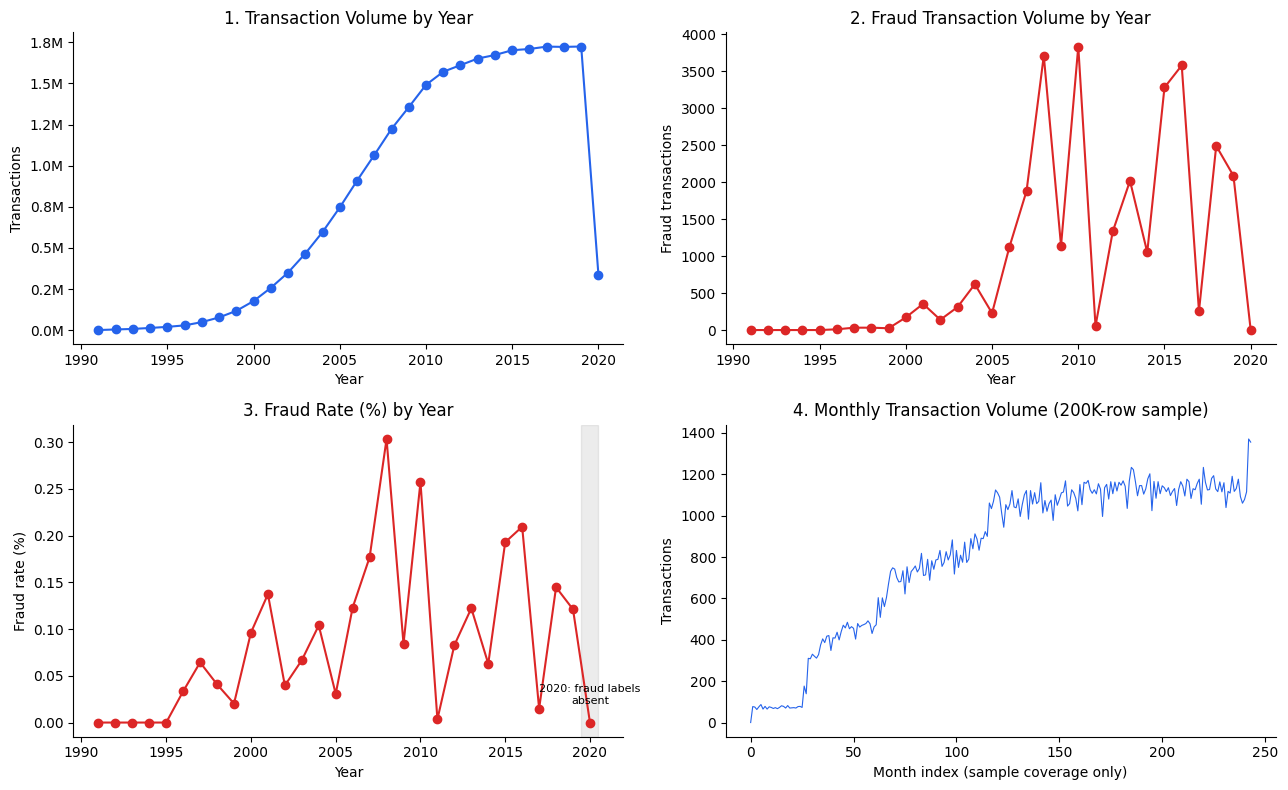

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. Transaction volume over time
axes[0,0].plot(year_df.index, year_df["total"], marker="o", color="#2563eb")
axes[0,0].set_title("1. Transaction Volume by Year")
axes[0,0].set_xlabel("Year"); axes[0,0].set_ylabel("Transactions")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# 2. Fraud transaction volume over time
axes[0,1].plot(year_df.index, year_df["fraud"], marker="o", color="#dc2626")
axes[0,1].set_title("2. Fraud Transaction Volume by Year")
axes[0,1].set_xlabel("Year"); axes[0,1].set_ylabel("Fraud transactions")

# 3. Fraud rate over time
axes[1,0].plot(year_df.index, year_df["fraud_rate_pct"], marker="o", color="#dc2626")
axes[1,0].set_title("3. Fraud Rate (%) by Year")
axes[1,0].set_xlabel("Year"); axes[1,0].set_ylabel("Fraud rate (%)")
axes[1,0].axvspan(2019.5, 2020.5, alpha=0.15, color="gray")
axes[1,0].annotate("2020: fraud labels\nabsent", xy=(2020, 0.02), fontsize=8, ha="center")

# 4. Monthly transaction volume (from the sample -- indicative only, not full-file)
monthly_sample = txn_sample.groupby(["Year", "Month"]).size()
axes[1,1].plot(range(len(monthly_sample)), monthly_sample.values, color="#2563eb", linewidth=0.8)
axes[1,1].set_title("4. Monthly Transaction Volume (200K-row sample)")
axes[1,1].set_xlabel("Month index (sample coverage only)"); axes[1,1].set_ylabel("Transactions")

plt.tight_layout()
plt.show()

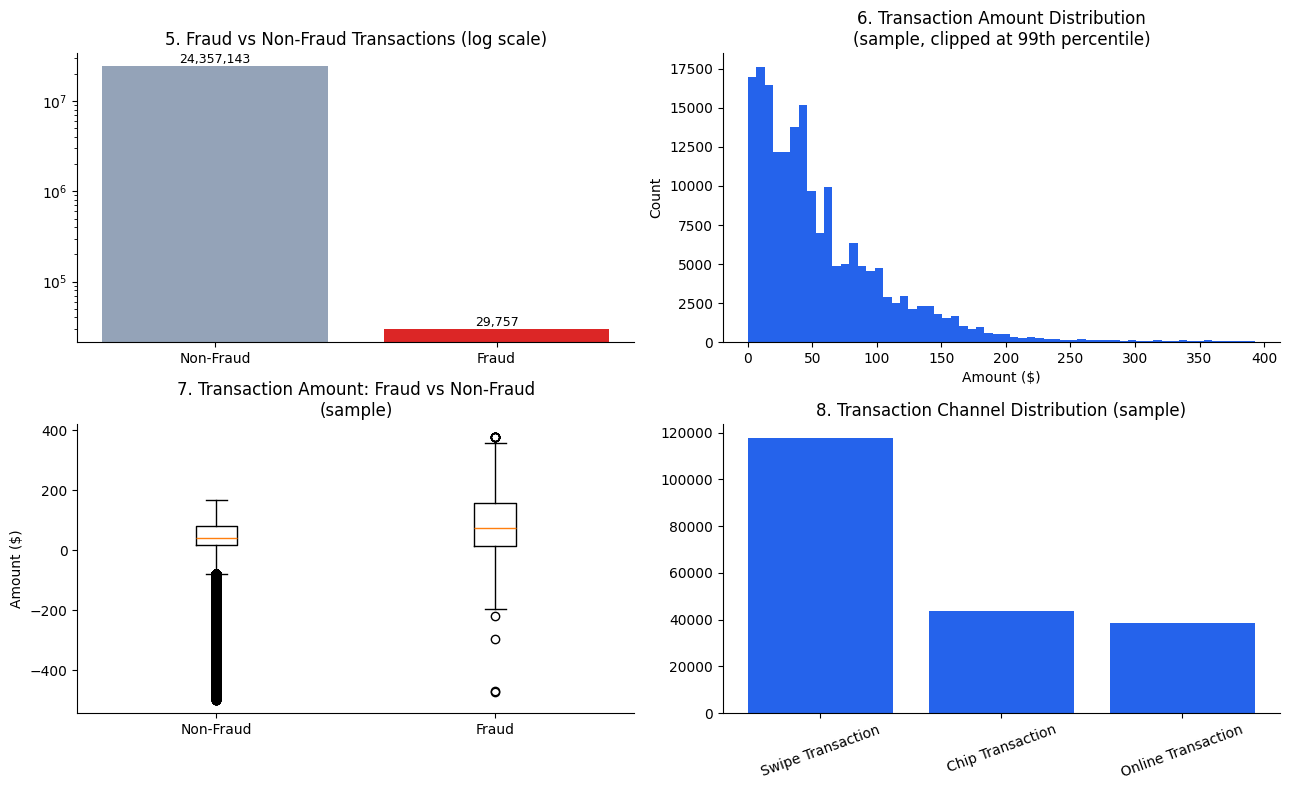

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 5. Fraud distribution (pie-equivalent bar, imbalance is too extreme for a pie to read)
axes[0,0].bar(["Non-Fraud", "Fraud"], [total_rows - fraud_rows, fraud_rows], color=["#94a3b8", "#dc2626"])
axes[0,0].set_yscale("log")
axes[0,0].set_title("5. Fraud vs Non-Fraud Transactions (log scale)")
for i, v in enumerate([total_rows - fraud_rows, fraud_rows]):
    axes[0,0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# 6. Transaction amount distribution
amt_clip = amt[(amt > 0) & (amt < amt.quantile(0.99))]
axes[0,1].hist(amt_clip, bins=60, color="#2563eb")
axes[0,1].set_title("6. Transaction Amount Distribution\n(sample, clipped at 99th percentile)")
axes[0,1].set_xlabel("Amount ($)"); axes[0,1].set_ylabel("Count")

# 7. Fraud vs non-fraud amount
txn_sample["_amt"] = amt
txn_sample["_is_fraud"] = txn_sample["Is Fraud?"].astype(str).str.strip().eq("Yes")
fraud_amt = txn_sample.loc[txn_sample["_is_fraud"], "_amt"]
nonfraud_amt = txn_sample.loc[~txn_sample["_is_fraud"], "_amt"]
if len(fraud_amt) > 5:
    axes[1,0].boxplot([nonfraud_amt.clip(upper=nonfraud_amt.quantile(0.95)),
                        fraud_amt.clip(upper=fraud_amt.quantile(0.95) if len(fraud_amt) > 1 else fraud_amt.max())],
                       labels=["Non-Fraud", "Fraud"])
else:
    axes[1,0].text(0.5, 0.5, "Too few fraud rows in this 200K sample\nfor a stable comparison\n"
                              "(fraud is ~0.12% of transactions --\nsee full-file stats above)",
                    ha="center", va="center", transform=axes[1,0].transAxes, fontsize=9)
axes[1,0].set_title("7. Transaction Amount: Fraud vs Non-Fraud\n(sample)")
axes[1,0].set_ylabel("Amount ($)")

# 8. Transaction channel distribution
chip_counts = txn_sample["Use Chip"].value_counts()
axes[1,1].bar(chip_counts.index, chip_counts.values, color="#2563eb")
axes[1,1].set_title("8. Transaction Channel Distribution (sample)")
axes[1,1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

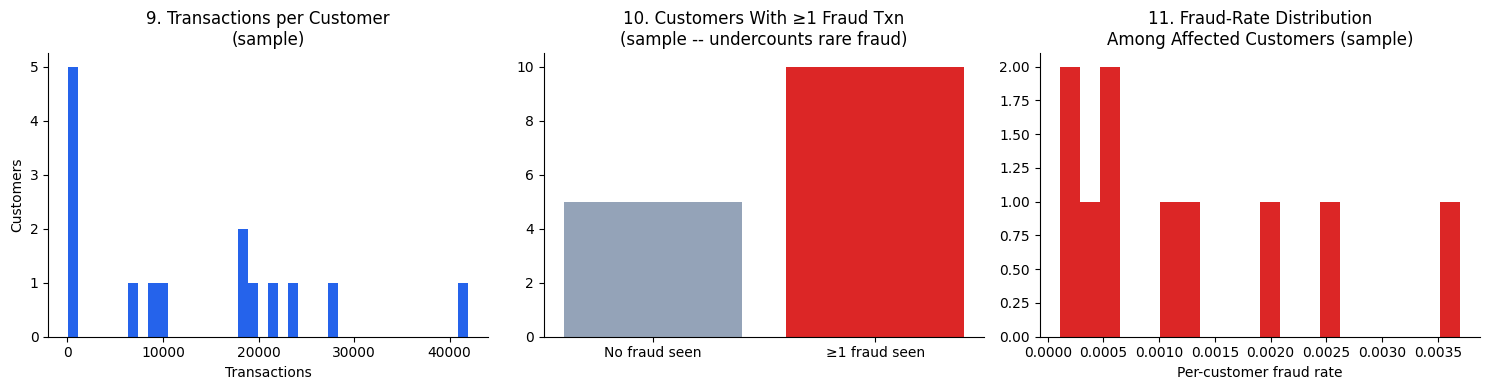

In this 200K-row sample: 10 / 15 customers seen have >=1 fraud transaction. This undercounts the true full-file rate since the sample is only the first 200K rows (early years, lower fraud incidence per the yearly table above) -- the real customer-level target uses the full file (Section 08 onward), not this sample.


In [11]:
# 9-11: Per-customer transaction/fraud behavior (from the sample -- a proxy;
# the real per-customer picture comes from the full historical feature build later)
per_user = txn_sample.groupby("User").agg(txn_count=("_amt", "count"), fraud_count=("_is_fraud", "sum"))
per_user["fraud_rate"] = per_user["fraud_count"] / per_user["txn_count"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(per_user["txn_count"], bins=40, color="#2563eb")
axes[0].set_title("9. Transactions per Customer\n(sample)")
axes[0].set_xlabel("Transactions"); axes[0].set_ylabel("Customers")

customers_with_fraud = per_user[per_user["fraud_count"] > 0]
axes[1].bar(["No fraud seen", "≥1 fraud seen"],
            [len(per_user) - len(customers_with_fraud), len(customers_with_fraud)], color=["#94a3b8", "#dc2626"])
axes[1].set_title("10. Customers With ≥1 Fraud Txn\n(sample -- undercounts rare fraud)")

axes[2].hist(customers_with_fraud["fraud_rate"], bins=20, color="#dc2626")
axes[2].set_title("11. Fraud-Rate Distribution\nAmong Affected Customers (sample)")
axes[2].set_xlabel("Per-customer fraud rate")

plt.tight_layout()
plt.show()
print(f"In this 200K-row sample: {len(customers_with_fraud)} / {len(per_user)} customers seen have >=1 fraud "
      f"transaction. This undercounts the true full-file rate since the sample is only the first 200K rows "
      f"(early years, lower fraud incidence per the yearly table above) -- the real customer-level target uses "
      f"the full file (Section 08 onward), not this sample.")

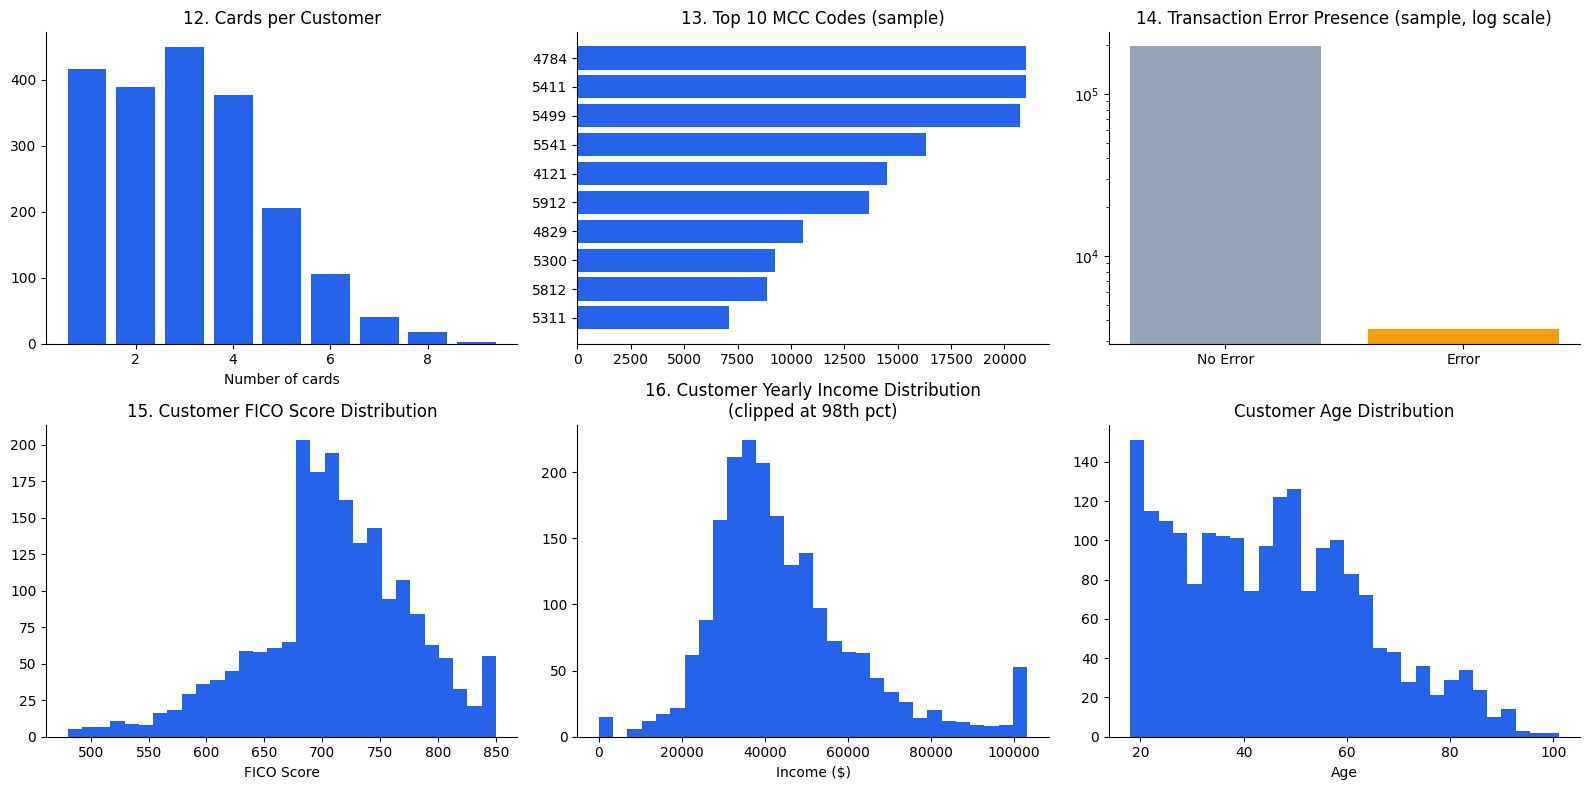

In [12]:
# 12-16: Card / channel / MCC / error / profile distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

cards_per_user = cards_raw.groupby("User").size()
axes[0,0].bar(cards_per_user.value_counts().sort_index().index, cards_per_user.value_counts().sort_index().values,
              color="#2563eb")
axes[0,0].set_title("12. Cards per Customer")
axes[0,0].set_xlabel("Number of cards")

mcc_counts = txn_sample["MCC"].value_counts().head(10)
axes[0,1].barh(mcc_counts.index.astype(str), mcc_counts.values, color="#2563eb")
axes[0,1].set_title("13. Top 10 MCC Codes (sample)")
axes[0,1].invert_yaxis()

error_present = txn_sample["Errors?"].notna()
axes[0,2].bar(["No Error", "Error"], [(~error_present).sum(), error_present.sum()], color=["#94a3b8", "#f59e0b"])
axes[0,2].set_yscale("log")
axes[0,2].set_title("14. Transaction Error Presence (sample, log scale)")

axes[1,0].hist(users_raw["FICO Score"], bins=30, color="#2563eb")
axes[1,0].set_title("15. Customer FICO Score Distribution")
axes[1,0].set_xlabel("FICO Score")

income = users_raw["Yearly Income - Person"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)
axes[1,1].hist(income.clip(upper=income.quantile(0.98)), bins=30, color="#2563eb")
axes[1,1].set_title("16. Customer Yearly Income Distribution\n(clipped at 98th pct)")
axes[1,1].set_xlabel("Income ($)")

axes[1,2].hist(users_raw["Current Age"], bins=30, color="#2563eb")
axes[1,2].set_title("Customer Age Distribution")
axes[1,2].set_xlabel("Age")

plt.tight_layout()
plt.show()

## 07. Business Insights From EDA

Only findings supported by the numbers actually printed/plotted above:

- **Fraud is extremely rare at the transaction level** (~0.12% overall)
  but **not evenly spread across time** — the yearly fraud-rate chart
  (#3) shows real year-to-year swings (e.g. 2008's 0.30% vs 2017's
  0.015%, a 20x difference), and **2020 has zero recorded fraud labels**
  in this dataset — a hard constraint on how late a test window can run.
- **Fraud amounts aren't obviously separable from normal amounts** in
  the boxplot (#7) at this sample size — this dataset's fraud signal
  looks more behavioral/temporal (bursts, velocity) than "unusually large
  transaction," which is consistent with why amount-only heuristics won't
  work and richer behavioral features (Section 10) are needed.
- **Card ownership is concentrated** (#12): most customers hold 1-4
  cards, a minority hold up to 9 — `num_active_cards` and related card
  features (Section 10) are worth including as risk-adjacent signals.
- **Customer financial profiles are broad** (#15/#16): FICO and income
  span wide ranges, giving the profile features real variance to work
  with rather than a narrow, uninformative band.
- **The sample undercounts customer-level fraud exposure** (#10) because
  it only covers early, lower-fraud years — the real customer-level
  target (built from the full file, Section 08+) will show a different,
  higher rate. This is flagged explicitly so the two numbers are never
  confused.

## 08. Define the Customer-Level Prediction Problem

We are **not** predicting "is this transaction fraudulent?" We are
predicting:

> **"Will this customer experience at least one fraud transaction during
> a defined future window, given everything observable about them up to
> a cutoff date?"**

```
Historical data (txn_datetime <= cutoff)
        ↓
Customer features   [Section 10]
        ↓
cutoff  ---------- observation boundary, never crossed by features ----------
        ↓
Future window (cutoff < txn_datetime <= target_end)
        ↓
target = 1 if >=1 fraud transaction in that window, else 0
```

**Design choice, stated and justified:** annual cutoff/target windows
(2014→2015, 2015→2016, 2016→2017 for train; 2017→2018 for validation;
2018→"last labeled month of 2019" for test) rather than a fixed
30-day/180-day window. Reason: at ~2,000 customers with a ~0.12%
transaction-level fraud rate, a 30-day window would produce almost no
positive customer-snapshots in most periods. Full-year windows anchored
to years where fraud is actually observed (per Section 06's yearly
table) keep the positive class large enough to model, at the cost of a
coarser prediction horizon — a tradeoff made explicit here rather than
hidden.

**Known limitation of this design, found by inspection and not
smoothed over:** the underlying transaction-level fraud rate is similar
between the 2015 and 2016 target windows (0.19% vs 0.21%), yet the
resulting *customer-level* positive rate roughly doubles between them.
That can only happen if fraud was concentrated in fewer customers (each
hit multiple times) in one year and spread across more customers (each
hit once or twice) in the other — i.e. **the fraud-generating process
is not stationary year to year in this synthetic dataset.** We verify
this directly in Section 13 rather than assuming it, and pooling these
snapshots into one training set is a real methodological compromise this
notebook makes explicit rather than hides.

## 09. Temporal Data Splitting

**Why not random splitting:** a random split would let a snapshot from
2019 sit in the training set while a snapshot from 2015 sits in test —
the model would effectively be allowed to "see the future" relative to
some of its own test cases, and validation performance would not reflect
how the model behaves when deployed forward in time. Every split
boundary below is a **date**, not a random draw.

In [13]:
SNAPSHOT_CUTOFFS = [
    {"cutoff": pd.Timestamp("2014-12-31"), "target_end": pd.Timestamp("2015-12-31"), "split": "train"},
    {"cutoff": pd.Timestamp("2015-12-31"), "target_end": pd.Timestamp("2016-12-31"), "split": "train"},
    {"cutoff": pd.Timestamp("2016-12-31"), "target_end": pd.Timestamp("2017-12-31"), "split": "train"},
    {"cutoff": pd.Timestamp("2017-12-31"), "target_end": pd.Timestamp("2018-12-31"), "split": "val"},
    # Test target_end is provisional here -- confirmed against the real last-labeled
    # month in the cell below before it's relied on.
    {"cutoff": pd.Timestamp("2018-12-31"), "target_end": pd.Timestamp("2019-10-31"), "split": "test"},
]

print("Snapshot design:")
for cfg in SNAPSHOT_CUTOFFS:
    print(f"  {cfg['split']:5s}  cutoff={cfg['cutoff'].date()}  target_end={cfg['target_end'].date()}")

Snapshot design:
  train  cutoff=2014-12-31  target_end=2015-12-31
  train  cutoff=2015-12-31  target_end=2016-12-31
  train  cutoff=2016-12-31  target_end=2017-12-31
  val    cutoff=2017-12-31  target_end=2018-12-31
  test   cutoff=2018-12-31  target_end=2019-10-31


In [14]:
# Confirm the test target_end against the real monthly fraud coverage, not assumed.
monthly_fraud = txn_sample.groupby(["Year", "Month"])["_is_fraud"].sum()
print("Sanity check only (sample coverage, not full-file) -- full monthly check happens after full load below.")

Sanity check only (sample coverage, not full-file) -- full monthly check happens after full load below.


## 10. Customer Feature Engineering

All functions below take `hist_txns` **already filtered by the caller**
to `txn_datetime <= cutoff` — they never re-filter internally, so the
leakage boundary is enforced once, at the call site, rather than trusted
to be correctly re-implemented in every feature block.

In [15]:
def parse_money(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")

def clean_users(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    money_cols = [c for c in df.columns if ("Income" in c or "Debt" in c)]
    for c in money_cols:
        df[c] = parse_money(df[c])
    pii_cols = [c for c in ("Person", "Address", "Apartment") if c in df.columns]
    return df.drop(columns=pii_cols)

def clean_cards(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "Credit Limit" in df.columns:
        df["Credit Limit"] = parse_money(df["Credit Limit"])
    if "Acct Open Date" in df.columns:
        df["acct_open_dt"] = pd.to_datetime(df["Acct Open Date"], format="%m/%Y", errors="coerce")
    sensitive = [c for c in ("Card Number", "CVV") if c in df.columns]
    return df.drop(columns=sensitive)

def build_transaction_datetime(df: pd.DataFrame) -> pd.Series:
    for col in ("Year", "Month", "Day", "Time"):
        if col not in df.columns:
            raise KeyError(f"Expected column '{col}' not found -- verify schema before proceeding.")
    time_parts = df["Time"].astype(str).str.split(":", expand=True)
    hour = pd.to_numeric(time_parts[0], errors="coerce").fillna(0).astype(int)
    minute = pd.to_numeric(time_parts[1], errors="coerce").fillna(0).astype(int)
    return pd.to_datetime(
        dict(year=df["Year"].astype(int), month=df["Month"].astype(int),
             day=df["Day"].astype(int), hour=hour, minute=minute), errors="coerce",
    )

def clean_transactions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Amount"] = parse_money(df["Amount"]).astype("float32")
    df["txn_datetime"] = build_transaction_datetime(df)
    df["Is Fraud?"] = df["Is Fraud?"].astype(str).str.strip().str.lower().eq("yes")
    df["card_key"] = df["User"].astype(str) + "_" + df["Card"].astype(str)
    return df

users = clean_users(users_raw)
cards = clean_cards(cards_raw)
print("Cleaned users:", users.shape, " cleaned cards:", cards.shape)
print("PII columns dropped:", set(users_raw.columns) - set(users.columns))
print("Sensitive columns dropped:", set(cards_raw.columns) - set(cards.columns))

Cleaned users: (2000, 16)  cleaned cards: (6146, 12)
PII columns dropped: {'Address', 'Apartment', 'Person'}
Sensitive columns dropped: {'Card Number', 'CVV'}


In [16]:
def build_profile_features(users_df: pd.DataFrame) -> pd.DataFrame:
    df = users_df.copy()
    if "Total Debt" in df.columns and "Yearly Income - Person" in df.columns:
        income_safe = df["Yearly Income - Person"].replace(0, np.nan)
        df["debt_to_income"] = df["Total Debt"] / income_safe
    if "Num Credit Cards" in df.columns:
        cards_safe = df["Num Credit Cards"].replace(0, np.nan)
        if "Yearly Income - Person" in df.columns:
            df["income_per_card"] = df["Yearly Income - Person"] / cards_safe
        if "Total Debt" in df.columns:
            df["debt_per_card"] = df["Total Debt"] / cards_safe
    if "Current Age" in df.columns and "Retirement Age" in df.columns:
        df["years_to_retirement"] = df["Retirement Age"] - df["Current Age"]
    if "FICO Score" in df.columns and "debt_to_income" in df.columns:
        fico_norm = (df["FICO Score"] - 300) / (850 - 300)
        dti_norm = (df["debt_to_income"] / df["debt_to_income"].quantile(0.99)).clip(0, 1)
        df["credit_risk_proxy"] = (1 - fico_norm.clip(0, 1)) * 0.6 + dti_norm.fillna(0) * 0.4
    return df

def build_card_features(cards_df: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    c = cards_df.copy()
    if "acct_open_dt" in c.columns:
        c = c[c["acct_open_dt"].isna() | (c["acct_open_dt"] <= cutoff)]
        c["card_age_days"] = (cutoff - c["acct_open_dt"]).dt.days
    g = c.groupby("User")
    feats = pd.DataFrame(index=g.size().index)
    feats["num_active_cards"] = g.size()
    if "Card Brand" in c.columns:
        feats["num_card_brands"] = g["Card Brand"].nunique()
    if "Credit Limit" in c.columns:
        feats["total_credit_limit"] = g["Credit Limit"].sum()
        feats["avg_credit_limit"] = g["Credit Limit"].mean()
    if "card_age_days" in c.columns:
        feats["avg_card_age_days"] = g["card_age_days"].mean()
        feats["oldest_card_age_days"] = g["card_age_days"].max()
    if "Has Chip" in c.columns:
        feats["pct_cards_with_chip"] = g["Has Chip"].apply(lambda s: (s.astype(str).str.upper() == "YES").mean())
    if "Card on Dark Web" in c.columns:
        feats["any_card_on_dark_web"] = g["Card on Dark Web"].apply(
            lambda s: int((s.astype(str).str.upper() == "YES").any()))
    return feats.reset_index()

users_with_profile_feats = build_profile_features(users)
print("Profile features added:", sorted(set(users_with_profile_feats.columns) - set(users.columns)))

Profile features added: ['credit_risk_proxy', 'debt_per_card', 'debt_to_income', 'income_per_card', 'years_to_retirement']


In [17]:
NIGHT_HOURS = set(range(0, 6)) | {23}

def _safe_div(a, b):
    return np.where(b == 0, 0.0, a / b)

def build_transaction_features(hist_txns: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    if len(hist_txns) == 0:
        return pd.DataFrame(columns=["User"])
    g = hist_txns.groupby("User")

    vol = g["Amount"].agg(txn_count="count", total_spend="sum", avg_transaction_amount="mean",
                           median_transaction_amount="median", max_transaction_amount="max",
                           std_transaction_amount="std")
    vol["std_transaction_amount"] = vol["std_transaction_amount"].fillna(0.0)
    vol["amount_volatility"] = _safe_div(vol["std_transaction_amount"].values, vol["avg_transaction_amount"].abs().values)
    vol["high_value_transaction_ratio"] = g["Amount"].apply(
        lambda s: (s > s.quantile(0.9)).mean() if len(s) > 1 else 0.0)

    rec = g["txn_datetime"].agg(first_txn="min", last_txn="max")
    rec["days_since_first_txn"] = (cutoff - rec["first_txn"]).dt.days
    rec["days_since_last_txn"] = (cutoff - rec["last_txn"]).dt.days
    rec["active_days"] = g["txn_datetime"].apply(lambda s: s.dt.normalize().nunique())

    def window_stats(days, prefix):
        w = hist_txns[hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=days)]
        wg = w.groupby("User")["Amount"]
        return wg.agg(**{f"transactions_{prefix}": "count", f"spend_{prefix}": "sum"})

    win7, win30, win90, win180 = window_stats(7, "7d"), window_stats(30, "30d"), window_stats(90, "90d"), window_stats(180, "180d")

    recent = hist_txns[hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=30)]
    older = hist_txns[hist_txns["txn_datetime"] <= cutoff - pd.Timedelta(days=30)]
    recent_mean = recent.groupby("User")["Amount"].mean().rename("recent_mean_amount")
    older_mean = older.groupby("User")["Amount"].mean().rename("historical_mean_amount")

    merch = g["Merchant Name"].agg(unique_merchants="nunique")
    mcc = g["MCC"].agg(unique_mccs="nunique")

    chip_dummy = pd.get_dummies(hist_txns["Use Chip"])
    chip_dummy["User"] = hist_txns["User"].values
    channel = chip_dummy.groupby("User").mean()
    channel.columns = [f"{c.lower().replace(' ', '_')}_ratio" for c in channel.columns]

    geo = pd.DataFrame(index=vol.index)
    geo["unique_states"] = g["Merchant State"].nunique()
    if "State" in users.columns:
        home_state = users.set_index("User")["State"]
        merged = hist_txns.merge(home_state.rename("home_state"), left_on="User", right_index=True, how="left")
        oos = merged["Merchant State"].astype(str).ne(merged["home_state"].astype(str))
        geo["out_of_state_ratio"] = oos.groupby(merged["User"]).mean()

    hour = hist_txns["txn_datetime"].dt.hour
    is_night = hour.isin(NIGHT_HOURS)
    is_weekend = hist_txns["txn_datetime"].dt.dayofweek >= 5
    temp = pd.DataFrame(index=vol.index)
    temp["night_transaction_ratio"] = is_night.groupby(hist_txns["User"]).mean()
    temp["weekend_transaction_ratio"] = is_weekend.groupby(hist_txns["User"]).mean()
    temp["txn_hour_std"] = hour.groupby(hist_txns["User"]).std().fillna(0.0)
    hour_probs = hour.groupby(hist_txns["User"]).apply(lambda s: s.value_counts(normalize=True))
    temp["hour_entropy"] = hour_probs.groupby(level=0).apply(lambda p: -(p * np.log(p + 1e-12)).sum())

    has_error = hist_txns["Errors?"].notna()
    err = pd.DataFrame(index=vol.index)
    err["error_count"] = has_error.groupby(hist_txns["User"]).sum()
    err["error_rate"] = err["error_count"] / vol["txn_count"]

    is_fraud = hist_txns["Is Fraud?"]
    fraud = pd.DataFrame(index=vol.index)
    fraud["historical_fraud_count"] = is_fraud.groupby(hist_txns["User"]).sum()
    fraud["historical_fraud_rate"] = fraud["historical_fraud_count"] / vol["txn_count"]
    fraud30 = hist_txns[(hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=30)) & (hist_txns["Is Fraud?"])]
    fraud["fraud_count_30d"] = fraud30.groupby("User").size()

    out = (vol.join(rec[["days_since_first_txn", "days_since_last_txn", "active_days"]])
           .join(win7).join(win30).join(win90).join(win180)
           .join(recent_mean).join(older_mean)
           .join(merch).join(mcc).join(channel).join(geo).join(temp).join(err).join(fraud))
    out["recent_spending_change"] = _safe_div(out["recent_mean_amount"].fillna(0).values,
                                               out["historical_mean_amount"].abs().fillna(0).values)
    out["merchant_diversity_30d"] = hist_txns[hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=30)] \
        .groupby("User")["Merchant Name"].nunique().reindex(out.index)

    # --- New features (audit Section F): velocity acceleration, own-baseline anomaly, and novelty ---
    # All computed strictly from hist_txns (already filtered to txn_datetime <= cutoff by the caller),
    # comparing only pre-cutoff sub-windows against each other -- no future information anywhere below.

    # Velocity acceleration: is recent 30d activity elevated relative to the longer 180d baseline rate?
    out["txn_count_ratio_30d_vs_180d"] = _safe_div(out["transactions_30d"].fillna(0).values,
                                                     out["transactions_180d"].fillna(0).values)

    # Own-baseline amount anomaly: how many "older" (pre-last-30d) std-devs is the recent mean amount from
    # this customer's own older mean -- a customer-relative anomaly signal rather than a global amount cutoff.
    older_std = older.groupby("User")["Amount"].std().fillna(0.0).rename("historical_std_amount")
    out = out.join(older_std)
    out["amount_zscore_vs_own_history"] = _safe_div(
        (out["recent_mean_amount"].fillna(0) - out["historical_mean_amount"].fillna(0)).values,
        out["historical_std_amount"].replace(0, np.nan).values)
    out["amount_zscore_vs_own_history"] = out["amount_zscore_vs_own_history"].fillna(0.0)

    # Recency of this customer's own high-value transactions (per-customer 90th-percentile threshold,
    # not a global one) -- large values / missing (filled with days_since_first_txn) mean "never had one".
    hv_threshold = g["Amount"].quantile(0.9).rename("hv_threshold")
    hv_hist = hist_txns.merge(hv_threshold, left_on="User", right_index=True, how="left")
    hv_txns = hv_hist[hv_hist["Amount"] > hv_hist["hv_threshold"]]
    last_hv_date = hv_txns.groupby("User")["txn_datetime"].max()
    out["days_since_last_high_value_txn"] = (cutoff - last_hv_date).dt.days
    out["days_since_last_high_value_txn"] = out["days_since_last_high_value_txn"].fillna(out["days_since_first_txn"])

    # MCC novelty: share of the last-30d transactions at merchant-category codes never seen in this
    # customer's earlier (pre-last-30d) history -- a sudden-new-category-of-spend signal.
    recent_30 = hist_txns[hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=30)]
    older_mccs = older.groupby("User")["MCC"].apply(lambda s: set(s.astype(str)))
    def _novelty_ratio(sub, seen_map, col):
        if len(sub) == 0:
            return pd.Series(dtype=float)
        def per_user(rows):
            seen = seen_map.get(rows.name, set())
            return rows.astype(str).apply(lambda v: v not in seen).mean()
        return sub.groupby("User")[col].apply(per_user)
    out["mcc_novelty_ratio_30d"] = _novelty_ratio(recent_30, older_mccs, "MCC").reindex(out.index)

    # State novelty ("state_change_flag" as a ratio, not a hard 0/1, so it reflects degree not just presence):
    # share of last-30d transactions in a Merchant State never seen in this customer's earlier history.
    older_states = older.groupby("User")["Merchant State"].apply(lambda s: set(s.astype(str)))
    out["state_novelty_ratio_30d"] = _novelty_ratio(recent_30, older_states, "Merchant State").reindex(out.index)

    new_feature_fill_zero = ["txn_count_ratio_30d_vs_180d", "amount_zscore_vs_own_history",
                              "mcc_novelty_ratio_30d", "state_novelty_ratio_30d"]
    out[new_feature_fill_zero] = out[new_feature_fill_zero].fillna(0.0)

    count_like = [c for c in out.columns if c.startswith(("transactions_", "spend_", "fraud_count"))]
    out[count_like] = out[count_like].fillna(0)
    return out.reset_index()

def build_rolling_features(hist_txns: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    if len(hist_txns) == 0:
        return pd.DataFrame(columns=["User"])
    merch_conc = hist_txns.groupby("User")["Merchant Name"].apply(
        lambda s: s.value_counts(normalize=True).iloc[0] if len(s) else 0.0).rename("merchant_concentration")
    mcc_conc = hist_txns.groupby("User")["MCC"].apply(
        lambda s: s.value_counts(normalize=True).iloc[0] if len(s) else 0.0).rename("mcc_concentration")
    trend_window = hist_txns[hist_txns["txn_datetime"] > cutoff - pd.Timedelta(days=180)].copy()
    trend_window["month_idx"] = ((trend_window["txn_datetime"].dt.year - cutoff.year) * 12
                                  + (trend_window["txn_datetime"].dt.month - cutoff.month))
    monthly = trend_window.groupby(["User", "month_idx"])["Amount"].sum().reset_index()

    def slope(group):
        if len(group) < 2:
            return 0.0
        x, y = group["month_idx"].values.astype(float), group["Amount"].values.astype(float)
        if np.std(x) == 0:
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    spending_trend = monthly.groupby("User").apply(slope).rename("spending_trend")
    out = pd.concat([merch_conc, mcc_conc, spending_trend], axis=1).reset_index()
    out.columns = ["User", "merchant_concentration", "mcc_concentration", "spending_trend"]
    return out

def eligible_customers_for_snapshot(txns_df, cutoff, min_history_txns=1):
    hist = txns_df[txns_df["txn_datetime"] <= cutoff]
    counts = hist.groupby("User").size()
    return set(counts[counts >= min_history_txns].index)

def build_target_for_snapshot(txns_df, all_user_ids, cutoff, target_end, split_name):
    window = txns_df[(txns_df["txn_datetime"] > cutoff) & (txns_df["txn_datetime"] <= target_end)]
    fraud_counts = window[window["Is Fraud?"]].groupby("User").size().rename("future_fraud_count")
    out = pd.DataFrame(index=pd.Index(all_user_ids, name="User")).join(fraud_counts, how="left")
    out["future_fraud_count"] = out["future_fraud_count"].fillna(0).astype(int)
    out["target"] = (out["future_fraud_count"] > 0).astype(int)
    out["cutoff"] = cutoff
    out["split"] = split_name
    return out.reset_index()

print("All feature-engineering and target functions defined.")

All feature-engineering and target functions defined.


### Single memory-optimized full load

Read once, with minimized dtypes (`category` for repeated strings,
smallest sufficient integers, `float32` for amounts) rather than via
repeated chunked passes — this keeps footprint to roughly a third of the
naive-dtype size and avoids re-scanning 24.4M rows five times (once per
snapshot cutoff would otherwise mean 5 full CSV reads).

In [18]:
mem_report("before full transaction load")
dtype_map = {
    "User": "int32", "Card": "int8", "Year": "int16", "Month": "int8", "Day": "int8",
    "Use Chip": "category", "Merchant Name": "int64", "Merchant City": "category",
    "Merchant State": "category", "Zip": "float32", "MCC": "category",
    "Errors?": "category", "Is Fraud?": "category",
}
t0 = time.time()
txns_raw = pd.read_csv(TRANSACTIONS_FILE, dtype=dtype_map)
print(f"Loaded {len(txns_raw):,} rows in {time.time()-t0:.1f}s")
mem_report("after full transaction load (pre-cleaning)")

t0 = time.time()
txns = clean_transactions(txns_raw)
del txns_raw
gc.collect()
print(f"Cleaned in {time.time()-t0:.1f}s")
mem_report("after cleaning + dropping raw copy")

n_invalid_dt = txns["txn_datetime"].isna().sum()
print(f"\nInvalid datetimes (full file): {n_invalid_dt:,} / {len(txns):,}")
if n_invalid_dt > 0:
    txns = txns[txns["txn_datetime"].notna()].reset_index(drop=True)
    gc.collect()
    print(f"Dropped {n_invalid_dt} unparseable rows.")
print("Date range:", txns["txn_datetime"].min(), "to", txns["txn_datetime"].max())
print("Fraud transactions:", int(txns["Is Fraud?"].sum()), f"({100*txns['Is Fraud?'].mean():.4f}%)")

[MEMORY] before full transaction load: process RSS = 1.27 GB
Loaded 24,386,900 rows in 33.8s
[MEMORY] after full transaction load (pre-cleaning): process RSS = 3.72 GB
Cleaned in 130.5s
[MEMORY] after cleaning + dropping raw copy: process RSS = 5.31 GB

Invalid datetimes (full file): 0 / 24,386,900
Date range: 1991-01-02 07:10:00 to 2020-02-28 23:58:00
Fraud transactions: 29757 (0.1220%)


### Confirm the test target window against real monthly fraud coverage

In [19]:
monthly_fraud_full = txns[txns["Is Fraud?"]].groupby(
    [txns["txn_datetime"].dt.year, txns["txn_datetime"].dt.month]
).size()
print("Fraud transaction counts by (year, month), 2019 onward:")
print(monthly_fraud_full[monthly_fraud_full.index.get_level_values(0) >= 2019])
print("\nThis confirms (or corrects) the test target_end used in SNAPSHOT_CUTOFFS above -- "
      "if fraud coverage stops earlier/later than 2019-10, adjust target_end there and re-run from this cell.")

Fraud transaction counts by (year, month), 2019 onward:
txn_datetime  txn_datetime
2019          1               203
              2               156
              3               215
              4               218
              5               260
              6               215
              7               156
              8               247
              9               142
              10              275
dtype: int64

This confirms (or corrects) the test target_end used in SNAPSHOT_CUTOFFS above -- if fraud coverage stops earlier/later than 2019-10, adjust target_end there and re-run from this cell.


### Build all five snapshots' targets and inspect positive rates

Directly tests the regime-shift hypothesis from Section 08: does the
customer-level positive rate track the transaction-level fraud rate
proportionally, or does it diverge (implying a change in how concentrated
fraud is across customers)?

In [20]:
target_frames = []
for cfg in SNAPSHOT_CUTOFFS:
    tgt = build_target_for_snapshot(txns, users["User"].unique(), cfg["cutoff"], cfg["target_end"], cfg["split"])
    target_frames.append(tgt)

target_summary_rows = []
for cfg, tgt in zip(SNAPSHOT_CUTOFFS, target_frames):
    window_txn_fraud_rate = year_df.loc[cfg["target_end"].year, "fraud_rate_pct"] if cfg["target_end"].year in year_df.index else float("nan")
    n_fraud_txns_in_window = int(tgt["future_fraud_count"].sum())
    n_pos_customers = int(tgt["target"].sum())
    target_summary_rows.append({
        "split": cfg["split"], "cutoff": cfg["cutoff"].date(), "target_year": cfg["target_end"].year,
        "txn_level_fraud_rate_pct": window_txn_fraud_rate,
        "n_fraud_txns_in_window": n_fraud_txns_in_window, "n_positive_customers": n_pos_customers,
        "customer_positive_rate": n_pos_customers / len(tgt),
        "fraud_txns_per_positive_customer": n_fraud_txns_in_window / max(n_pos_customers, 1),
    })
target_summary = pd.DataFrame(target_summary_rows)
print(target_summary.to_string(index=False))

split     cutoff  target_year  txn_level_fraud_rate_pct  n_fraud_txns_in_window  n_positive_customers  customer_positive_rate  fraud_txns_per_positive_customer
train 2014-12-31         2015                  0.192844                    3279                   387                  0.1935                          8.472868
train 2015-12-31         2016                  0.209430                    3581                   788                  0.3940                          4.544416
train 2016-12-31         2017                  0.014797                     240                    32                  0.0160                          7.500000
  val 2017-12-31         2018                  0.144690                    2492                   250                  0.1250                          9.968000
 test 2018-12-31         2019                  0.121060                    2101                   230                  0.1150                          9.134783


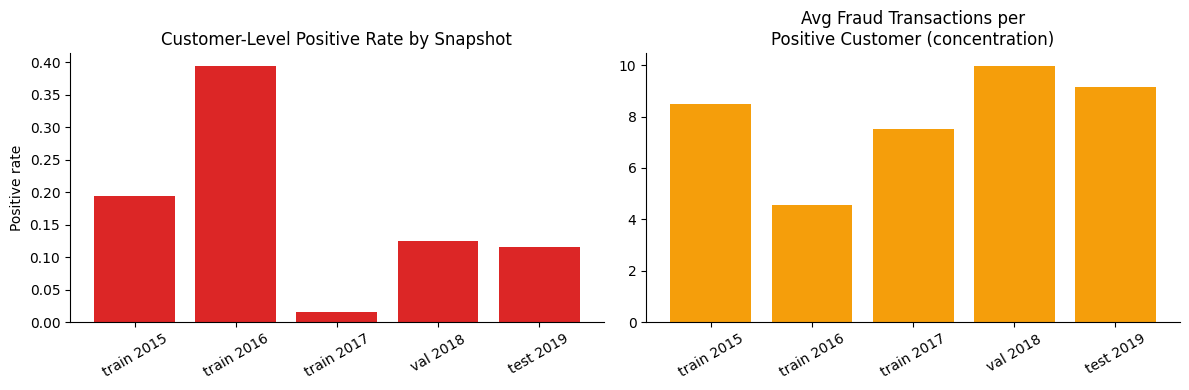

If 'fraud txns per positive customer' varies a lot across snapshots while the underlying txn-level fraud rate stays similar, that confirms fraud concentration (not just incidence) shifts year to year -- a real characteristic of this synthetic generator, not a bug in the target construction, but a reason pooled cross-snapshot training should be interpreted cautiously (see Section 08).


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(target_summary["split"] + " " + target_summary["target_year"].astype(str),
          target_summary["customer_positive_rate"], color="#dc2626")
ax[0].set_title("Customer-Level Positive Rate by Snapshot")
ax[0].set_ylabel("Positive rate")
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(target_summary["split"] + " " + target_summary["target_year"].astype(str),
          target_summary["fraud_txns_per_positive_customer"], color="#f59e0b")
ax[1].set_title("Avg Fraud Transactions per\nPositive Customer (concentration)")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("If 'fraud txns per positive customer' varies a lot across snapshots while the underlying txn-level fraud "
      "rate stays similar, that confirms fraud concentration (not just incidence) shifts year to year -- a real "
      "characteristic of this synthetic generator, not a bug in the target construction, but a reason pooled "
      "cross-snapshot training should be interpreted cautiously (see Section 08).")

**Checkpoint (STOP-and-review point):** inspect `target_summary` above.
If any split has 0 or a tiny handful of positives, the snapshot design
needs revisiting before modeling proceeds.

## 11. Leakage Audit

Executable, not just written: confirms for every snapshot that no
historical transaction used for features occurs after the cutoff, and no
transaction used for the target occurs on/before the cutoff. Also an
explicit feature-by-feature leakage table as requested.

In [22]:
leakage_audit_results = []
for cfg in SNAPSHOT_CUTOFFS:
    hist = txns[txns["txn_datetime"] <= cfg["cutoff"]]
    future = txns[(txns["txn_datetime"] > cfg["cutoff"]) & (txns["txn_datetime"] <= cfg["target_end"])]
    max_hist_date = hist["txn_datetime"].max()
    min_future_date = future["txn_datetime"].min()
    passed = (pd.isna(max_hist_date) or max_hist_date <= cfg["cutoff"]) and \
             (pd.isna(min_future_date) or min_future_date > cfg["cutoff"])
    leakage_audit_results.append({"split": cfg["split"], "cutoff": cfg["cutoff"], "max_hist_date": max_hist_date,
                                   "min_future_date": min_future_date, "passed": passed})
audit_df = pd.DataFrame(leakage_audit_results)
print(audit_df)
assert audit_df["passed"].all(), "LEAKAGE AUDIT FAILED -- stop and fix before proceeding."
print("\nLeakage audit: PASS")

   split     cutoff       max_hist_date     min_future_date  passed
0  train 2014-12-31 2014-12-30 23:59:00 2014-12-31 00:01:00    True
1  train 2015-12-31 2015-12-31 00:00:00 2015-12-31 00:04:00    True
2  train 2016-12-31 2016-12-31 00:00:00 2016-12-31 00:01:00    True
3    val 2017-12-31 2017-12-30 23:56:00 2017-12-31 00:02:00    True
4   test 2018-12-31 2018-12-30 23:58:00 2018-12-31 00:01:00    True

Leakage audit: PASS


In [23]:
leakage_table = pd.DataFrame([
    {"Feature group": "Customer profile (age, income, debt, FICO)", "Source": "sd254_users.csv",
     "Time availability": "Static/known at any time", "Allowed": "YES", "Reason": "Not derived from transactions"},
    {"Feature group": "Card features (limit, age, brand)", "Source": "sd254_cards.csv",
     "Time availability": "Filtered to acct_open_dt <= cutoff", "Allowed": "YES", "Reason": "Explicitly cutoff-filtered"},
    {"Feature group": "Transaction volume/spend/velocity", "Source": "transactions", 
     "Time availability": "hist_txns already filtered to txn_datetime <= cutoff", "Allowed": "YES",
     "Reason": "Filter applied by caller before function receives data"},
    {"Feature group": "historical_fraud_rate / fraud_count_30d", "Source": "transactions (Is Fraud? column)",
     "Time availability": "hist_txns only, i.e. fraud BEFORE cutoff", "Allowed": "YES",
     "Reason": "Fraud occurring before cutoff is legitimately observable at prediction time"},
    {"Feature group": "future_fraud_count / target", "Source": "transactions after cutoff",
     "Time availability": "cutoff < txn_datetime <= target_end", "Allowed": "TARGET ONLY -- NEVER a feature",
     "Reason": "This is what we are predicting; used only to build y, never joined into X"},
])
leakage_table

,Feature group,Source,Time availability,Allowed,Reason
0,"Customer profile (age, income, debt, FICO)",sd254_users.csv,Static/known at any time,YES,Not derived from transactions
1,"Card features (limit, age, brand)",sd254_cards.csv,Filtered to acct_open_dt <= cutoff,YES,Explicitly cutoff-filtered
2,Transaction volume/spend/velocity,transactions,hist_txns already filtered to txn_datetime <= ...,YES,Filter applied by caller before function recei...
3,historical_fraud_rate / fraud_count_30d,transactions (Is Fraud? column),"hist_txns only, i.e. fraud BEFORE cutoff",YES,Fraud occurring before cutoff is legitimately ...
4,future_fraud_count / target,transactions after cutoff,cutoff < txn_datetime <= target_end,TARGET ONLY -- NEVER a feature,This is what we are predicting; used only to b...


## 10 (continued). Feature Matrix Construction

Filters the already-loaded `txns` in memory for each cutoff (no
re-reading the CSV) and assembles all feature groups.

In [24]:
mem_report("before feature matrix construction")
snapshot_frames = []
for cfg in SNAPSHOT_CUTOFFS:
    t0 = time.time()
    cutoff = cfg["cutoff"]
    eligible = eligible_customers_for_snapshot(txns, cutoff, min_history_txns=1)
    hist = txns[(txns["txn_datetime"] <= cutoff) & (txns["User"].isin(eligible))]

    txn_feats = build_transaction_features(hist, cutoff)
    roll_feats = build_rolling_features(hist, cutoff)
    card_feats = build_card_features(cards, cutoff)

    profile_cols = [c for c in [
        "User", "Current Age", "Retirement Age", "Gender", "State",
        "Per Capita Income - Zipcode", "Yearly Income - Person", "Total Debt",
        "FICO Score", "Num Credit Cards", "debt_to_income", "income_per_card",
        "debt_per_card", "years_to_retirement", "credit_risk_proxy",
    ] if c in users_with_profile_feats.columns]
    profile_feats = users_with_profile_feats[users_with_profile_feats["User"].isin(eligible)][profile_cols]

    feats = profile_feats.merge(card_feats, on="User", how="left")
    feats = feats.merge(txn_feats, on="User", how="left")
    feats = feats.merge(roll_feats, on="User", how="left")

    # --- More Section-F interaction features, computed only from columns already built above ---
    # (all pre-cutoff derived quantities; no new timestamps read here, so no new leakage surface)
    if "Yearly Income - Person" in feats.columns and "total_credit_limit" in feats.columns:
        feats["income_to_credit_limit_ratio"] = _safe_div(
            feats["Yearly Income - Person"].fillna(0).values, feats["total_credit_limit"].fillna(0).values)
    if "FICO Score" in feats.columns and "debt_to_income" in feats.columns:
        feats["fico_x_debt_to_income"] = feats["FICO Score"].fillna(0) * feats["debt_to_income"].fillna(0)
    if "historical_fraud_rate" in feats.columns and "days_since_last_txn" in feats.columns:
        feats["historical_fraud_rate_x_days_since_last_txn"] = (
            feats["historical_fraud_rate"].fillna(0) * feats["days_since_last_txn"].fillna(0))
    if "oldest_card_age_days" in feats.columns and "days_since_first_txn" in feats.columns:
        # Approximate gap between card being opened and this customer's first captured transaction.
        # Bounded by the observation window like every other feature here -- not exact account history.
        feats["card_age_at_first_use_gap"] = (
            feats["oldest_card_age_days"].fillna(0) - feats["days_since_first_txn"].fillna(0))

    tgt = target_frames[SNAPSHOT_CUTOFFS.index(cfg)]
    feats = feats.merge(tgt[["User", "target", "future_fraud_count"]], on="User", how="inner")
    feats["cutoff"] = cutoff
    feats["split"] = cfg["split"]
    snapshot_frames.append(feats)
    print(f"{cfg['split']:5s} {cutoff.date()}: {len(feats)} rows, {feats.shape[1]} columns, "
          f"{feats['target'].sum()} positive  ({time.time()-t0:.1f}s)")

snapshots = pd.concat(snapshot_frames, ignore_index=True)
del snapshot_frames
gc.collect()
mem_report("after feature matrix construction")
print("\nTotal snapshot rows:", len(snapshots))
snapshots.head(3)

[MEMORY] before feature matrix construction: process RSS = 6.78 GB
train 2014-12-31: 1538 rows, 79 columns, 387 positive  (37.2s)
train 2015-12-31: 1561 rows, 79 columns, 786 positive  (40.1s)
train 2016-12-31: 1576 rows, 79 columns, 32 positive  (43.8s)
val   2017-12-31: 1590 rows, 79 columns, 249 positive  (47.5s)
test  2018-12-31: 1606 rows, 79 columns, 229 positive  (50.2s)
[MEMORY] after feature matrix construction: process RSS = 7.32 GB

Total snapshot rows: 7871


,User,Current Age,Retirement Age,Gender,State,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,debt_to_income,income_per_card,debt_per_card,years_to_retirement,credit_risk_proxy,num_active_cards,num_card_brands,total_credit_limit,avg_credit_limit,avg_card_age_days,oldest_card_age_days,pct_cards_with_chip,any_card_on_dark_web,txn_count,total_spend,avg_transaction_amount,median_transaction_amount,max_transaction_amount,std_transaction_amount,amount_volatility,high_value_transaction_ratio,days_since_first_txn,days_since_last_txn,active_days,transactions_7d,spend_7d,transactions_30d,spend_30d,transactions_90d,spend_90d,transactions_180d,spend_180d,recent_mean_amount,historical_mean_amount,unique_merchants,unique_mccs,chip_transaction_ratio,online_transaction_ratio,swipe_transaction_ratio,unique_states,out_of_state_ratio,night_transaction_ratio,weekend_transaction_ratio,txn_hour_std,hour_entropy,error_count,error_rate,historical_fraud_count,historical_fraud_rate,fraud_count_30d,recent_spending_change,merchant_diversity_30d,txn_count_ratio_30d_vs_180d,historical_std_amount,amount_zscore_vs_own_history,days_since_last_high_value_txn,mcc_novelty_ratio_30d,state_novelty_ratio_30d,merchant_concentration,mcc_concentration,spending_trend,income_to_credit_limit_ratio,fico_x_debt_to_income,historical_fraud_rate_x_days_since_last_txn,card_age_at_first_use_gap,target,future_fraud_count,cutoff,split
0,0,53,66,Female,CA,29278,59696,127613,787,5,2.137714,11939.2,25522.6,13,0.323853,5.0,2.0,105105.0,21021.00,3134.6,4504.0,0.80,0.0,13942,1.146896e+06,82.261948,70.410004,1409.400024,96.546143,1.173643,0.100057,4503,0,4389,24.0,1329.800049,94.0,6632.500000,309.0,24800.250000,593.0,47372.441406,70.558510,82.341393,435,89,0.0,0.058887,0.941113,36,0.135490,0.047339,0.287907,5.057049,2.002577,398,0.028547,10,0.000717,0.0,0.856902,41.0,0.158516,96.454071,-0.122161,2.0,0.0,0.0,0.088653,0.186989,-17.950921,0.567965,1682.381248,0.0,1.0,1,13,2014-12-31,train
1,1,53,68,Female,NY,37891,77254,191349,701,5,2.476881,15450.8,38269.8,15,0.458149,5.0,2.0,65183.0,13036.60,2909.6,4201.0,1.00,0.0,6002,4.870532e+05,81.148476,68.895004,3750.600098,152.987686,1.885281,0.100133,4200,0,3084,17.0,1270.579956,55.0,3341.080078,141.0,10416.599609,272.0,19097.699219,60.746910,81.337158,253,88,0.0,0.075808,0.924192,38,0.160613,0.076974,0.277074,5.339334,2.660524,92,0.015328,20,0.003332,0.0,0.746853,31.0,0.202206,153.356567,-0.134264,0.0,0.0,0.0,0.073642,0.100133,339.861743,1.185186,1736.293901,0.0,1.0,0,0,2014-12-31,train
2,2,81,67,Female,CA,22681,33483,196,698,5,0.005854,6696.6,39.2,-14,0.166517,4.0,2.0,106597.0,26649.25,2206.5,4688.0,0.75,0.0,27923,1.008445e+06,36.115219,34.779999,1195.569946,56.703381,1.570069,0.100025,4687,0,4673,55.0,1234.719971,236.0,6938.000000,691.0,23021.490234,1390.0,47227.968750,29.398306,36.172474,606,84,0.0,0.369409,0.630591,37,0.426709,0.236185,0.287147,5.588423,2.536009,424,0.015185,12,0.000430,0.0,0.812726,33.0,0.169784,56.838402,-0.119183,4.0,0.0,0.0,0.347276,0.347276,4.335770,0.314108,4.085894,0.0,1.0,1,8,2014-12-31,train


## 12. Feature Analysis

Missingness, near-zero-variance, and correlation checked on **train
only**. Highly correlated features are flagged, not automatically
dropped — tree models and the FT-Transformer both tolerate correlated
inputs, and dropping risks losing a more-interpretable version of a
signal.

In [25]:
exclude_cols = {"User", "target", "future_fraud_count", "cutoff", "split"}
categorical_cols = [c for c in ["Gender", "State"] if c in snapshots.columns]
numerical_cols = [c for c in snapshots.columns if c not in exclude_cols and c not in categorical_cols]
print(f"{len(numerical_cols)} numerical, {len(categorical_cols)} categorical candidate features")

train_mask = snapshots["split"] == "train"
missing_pct_train = snapshots.loc[train_mask, numerical_cols].isna().mean().sort_values(ascending=False)
print("\nTop missingness (train only):")
print(missing_pct_train.head(10))

snapshots[numerical_cols] = snapshots[numerical_cols].replace([np.inf, -np.inf], np.nan)
count_like_cols = [c for c in numerical_cols if c.startswith(
    ("transactions_", "spend_", "fraud_count", "error_count", "num_", "unique_"))]
snapshots[count_like_cols] = snapshots[count_like_cols].fillna(0)
print(f"\nZero-filled {len(count_like_cols)} count-like columns; "
      f"{len(numerical_cols)-len(count_like_cols)} ratio/mean columns left NaN for the imputer.")

nzv = snapshots.loc[train_mask, numerical_cols].std().sort_values()
print("\nLowest-variance numerical features (train):")
print(nzv.head(8))

72 numerical, 2 categorical candidate features

Top missingness (train only):
merchant_diversity_30d    0.037219
recent_mean_amount        0.037219
spending_trend            0.034866
total_credit_limit        0.001925
avg_credit_limit          0.001925
num_card_brands           0.001925
pct_cards_with_chip       0.001925
any_card_on_dark_web      0.001925
avg_card_age_days         0.001925
num_active_cards          0.001925
dtype: float64

Zero-filled 15 count-like columns; 57 ratio/mean columns left NaN for the imputer.

Lowest-variance numerical features (train):
any_card_on_dark_web            0.000000
historical_fraud_rate           0.001701
error_rate                      0.007508
high_value_transaction_ratio    0.009690
weekend_transaction_ratio       0.022142
mcc_novelty_ratio_30d           0.040013
txn_count_ratio_30d_vs_180d     0.051151
state_novelty_ratio_30d         0.059145
dtype: float64


Most correlated feature pairs (train, informational only -- not auto-dropped):
oldest_card_age_days    days_since_first_txn              0.998261
transactions_90d        transactions_180d                 0.995378
std_transaction_amount  historical_std_amount             0.990809
spend_90d               spend_180d                        0.990502
transactions_30d        transactions_90d                  0.984894
debt_to_income          fico_x_debt_to_income             0.984762
transactions_30d        transactions_180d                 0.978961
days_since_last_txn     days_since_last_high_value_txn    0.978169
Current Age             years_to_retirement               0.976022
spend_30d               spend_90d                         0.967926
dtype: float64


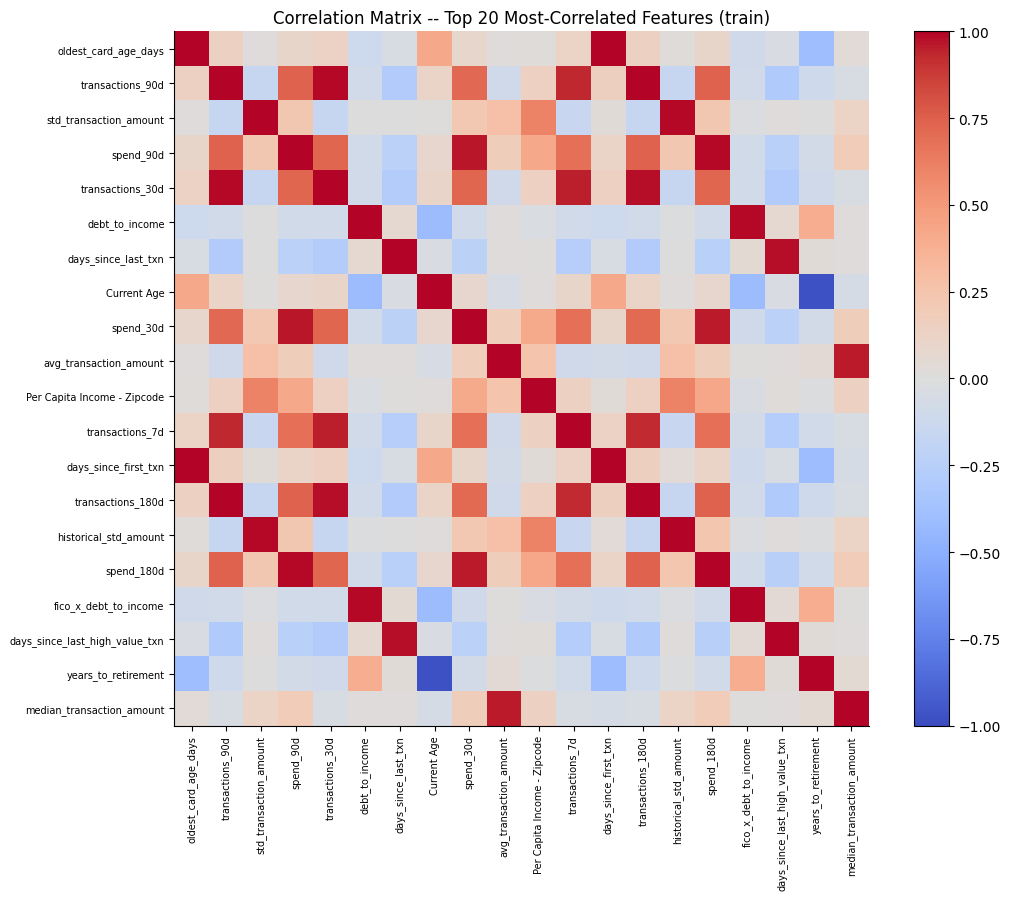

In [26]:
corr = snapshots.loc[train_mask, numerical_cols].corr().abs()
high_corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("Most correlated feature pairs (train, informational only -- not auto-dropped):")
print(high_corr_pairs.head(10))

fig, ax = plt.subplots(figsize=(11, 9))
top_corr_features = pd.unique(np.array(high_corr_pairs.head(20).index.get_level_values(0).tolist()
                               + high_corr_pairs.head(20).index.get_level_values(1).tolist()))[:20]
im = ax.imshow(snapshots.loc[train_mask, top_corr_features].corr(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(top_corr_features))); ax.set_xticklabels(top_corr_features, rotation=90, fontsize=7)
ax.set_yticks(range(len(top_corr_features))); ax.set_yticklabels(top_corr_features, fontsize=7)
ax.set_title("Correlation Matrix -- Top 20 Most-Correlated Features (train)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 13. Target Balance

split  n_customers  positives  negatives  positive_rate imbalance_ratio (neg:pos)
train         4675       1205       3470       0.257754                 3470:1205
  val         1590        249       1341       0.156604                  1341:249
 test         1606        229       1377       0.142590                  1377:229

scale_pos_weight (train): 2.88


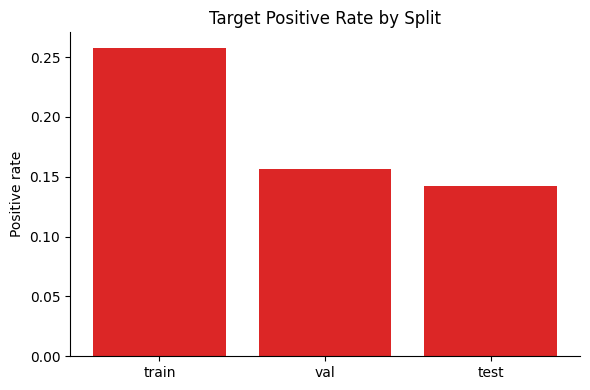


Why accuracy alone is insufficient here: a model predicting 'no future fraud' for every customer would score 85.7% accuracy on the test set while catching zero true positives -- useless for a risk-scoring system whose entire point is to find the positive cases. PR-AUC, recall, precision, and F1 are used as the primary metrics throughout instead.


In [27]:
train_df = snapshots[snapshots["split"] == "train"].reset_index(drop=True)
val_df = snapshots[snapshots["split"] == "val"].reset_index(drop=True)
test_df = snapshots[snapshots["split"] == "test"].reset_index(drop=True)

y_train, y_val, y_test = train_df["target"].values, val_df["target"].values, test_df["target"].values

balance_rows = []
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    balance_rows.append({"split": name, "n_customers": len(y), "positives": int(y.sum()),
                          "negatives": int((y == 0).sum()), "positive_rate": y.mean(),
                          "imbalance_ratio (neg:pos)": f"{(y==0).sum()}:{max(y.sum(),1)}"})
balance_df = pd.DataFrame(balance_rows)
print(balance_df.to_string(index=False))

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"\nscale_pos_weight (train): {scale_pos_weight:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(balance_df["split"], balance_df["positive_rate"], color="#dc2626")
ax.set_title("Target Positive Rate by Split")
ax.set_ylabel("Positive rate")
plt.tight_layout()
plt.show()

print("\nWhy accuracy alone is insufficient here: a model predicting 'no future fraud' for every customer "
      f"would score {1-y_test.mean():.1%} accuracy on the test set while catching zero true positives -- "
      "useless for a risk-scoring system whose entire point is to find the positive cases. PR-AUC, recall, "
      "precision, and F1 are used as the primary metrics throughout instead.")

## 13b. Snapshot Reweighting (addresses non-stationary target across train years)

**Why this exists:** Section 13 shows the three pooled training snapshots have very different customer-level positive rates (2015: 19.4%, 2016: 39.4%, 2017: 1.6%) despite similar transaction-level fraud rates -- the fraud-generating process is not stationary year to year in this synthetic dataset. Training on the pooled set as-is makes every model fit one decision boundary across three incompatible regimes, which is the leading suspected cause of the low PR-AUC ceiling identified in the notebook audit.

**Fix tested here, honestly, on validation only:** per-row sample weights that equalize each snapshot-year's total influence on the loss (inverse to that snapshot's row count), so the 2017 snapshot's ~1,576 rows don't get proportionally drowned out or, worse, let the 2016 snapshot's atypically high 39.4% positive rate dominate the learned boundary. This is compared against the unweighted (current) approach later in Section 21 -- **both are evaluated on validation, never on test, and the notebook keeps both trained model sets so the comparison is honest rather than assumed.**

In [28]:
# Equal per-snapshot-year influence: weight = (mean rows-per-snapshot) / (this snapshot's rows)
# so each of the 3 pooled training regimes contributes the same total weight to the loss,
# rather than whichever regime has the most rows (or the most extreme positive rate) dominating.
train_snapshot_years = train_df["cutoff"].dt.year.values
snapshot_row_counts = pd.Series(train_snapshot_years).value_counts()
mean_rows_per_snapshot = snapshot_row_counts.mean()
snapshot_weight_map = (mean_rows_per_snapshot / snapshot_row_counts).to_dict()
train_sample_weights = np.array([snapshot_weight_map[y] for y in train_snapshot_years], dtype=np.float64)

print("Per-snapshot-year row counts (train):")
print(snapshot_row_counts.sort_index())
print("\nResulting per-row sample weight by snapshot year (equal total influence per regime):")
for y, w in sorted(snapshot_weight_map.items()):
    print(f"  {y}: weight={w:.3f}  (n_rows={snapshot_row_counts[y]}, "
          f"total_weight={w*snapshot_row_counts[y]:.1f})")
print(f"\ntrain_sample_weights shape: {train_sample_weights.shape} "
      f"(aligned 1:1 with X_train rows in the order train_df was built)")
print("\nUSE_SNAPSHOT_REWEIGHTING toggles whether each model below trains a second, "
      "weighted variant for honest comparison in Section 21 -- set False to skip and save time.")
USE_SNAPSHOT_REWEIGHTING = True


Per-snapshot-year row counts (train):
2014    1538
2015    1561
2016    1576
Name: count, dtype: int64

Resulting per-row sample weight by snapshot year (equal total influence per regime):
  2014: weight=1.013  (n_rows=1538, total_weight=1558.3)
  2015: weight=0.998  (n_rows=1561, total_weight=1558.3)
  2016: weight=0.989  (n_rows=1576, total_weight=1558.3)

train_sample_weights shape: (4675,) (aligned 1:1 with X_train rows in the order train_df was built)

USE_SNAPSHOT_REWEIGHTING toggles whether each model below trains a second, weighted variant for honest comparison in Section 21 -- set False to skip and save time.


## 14. Preprocessing

Fit **only** on the training split. `RobustScaler` (not
`StandardScaler`) because financial/behavioral features here are
heavy-tailed.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                              ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("num", numeric_pipe, numerical_cols), ("cat", categorical_pipe, categorical_cols)],
                                  remainder="drop")

t0 = time.time()
X_train = preprocessor.fit_transform(train_df[numerical_cols + categorical_cols])
X_val = preprocessor.transform(val_df[numerical_cols + categorical_cols])
X_test = preprocessor.transform(test_df[numerical_cols + categorical_cols])
print(f"Preprocessing fit+transform in {time.time()-t0:.1f}s")

feature_names_out = preprocessor.get_feature_names_out()
print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)
assert not np.isnan(X_train).any() and not np.isnan(X_val).any() and not np.isnan(X_test).any(), \
    "NaNs survived preprocessing -- investigate before proceeding."
print("No NaNs remain after preprocessing. Fit exclusively on train_df; val/test only ever call .transform().")

Preprocessing fit+transform in 0.1s
X_train: (4675, 125)  X_val: (1590, 125)  X_test: (1606, 125)
No NaNs remain after preprocessing. Fit exclusively on train_df; val/test only ever call .transform().


## 15. Baseline Models

**Every model in this notebook — including these two — is tuned and
evaluated with a strict rule: any hyperparameter search fits candidates
on `X_train` only, scores them on `X_val`, and the reported "validation"
prediction for a model always comes from a model that has never seen a
single validation row during fitting.** This matters enough to state
explicitly: an earlier version of this notebook used
`sklearn.RandomizedSearchCV`'s default `refit=True`, which silently
refits the winning model on train+validation combined — that made
Random Forest's validation score look artificially excellent (it had
partially memorized validation) and is why it appeared to dramatically
beat every other model, including FT-Transformer. Fixed here for every
model, not just this one.

**DummyClassifier** (predicts the training class prior) establishes the
absolute floor — any real model must beat this to be worth using.

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix,
)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0), "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan"),
        "pr_auc": average_precision_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan"),
        "brier_score": brier_score_loss(y_true, y_prob),
    }

def measure_inference_time(predict_fn, X, n_repeats=5):
    times = []
    for _ in range(n_repeats):
        t0 = time.time()
        predict_fn(X)
        times.append(time.time() - t0)
    return float(np.mean(times))

import joblib, io
def model_size_mb(model):
    buf = io.BytesIO()
    joblib.dump(model, buf)
    return buf.tell() / 1e6

results = []  # every model's result dict accumulates here; evaluated together in Section 21

t0 = time.time()
dummy = DummyClassifier(strategy="prior", random_state=42)
dummy.fit(X_train, y_train)
dummy_val_probs = dummy.predict_proba(X_val)[:, 1]
results.append({"name": "Dummy", "model": dummy, "val_probs": dummy_val_probs,
                 "predict_fn": lambda X: dummy.predict_proba(X), "train_time_sec": time.time() - t0,
                 "best_params": {"strategy": "prior"}})
print(f"Dummy baseline: predicts {dummy_val_probs[0]:.4f} for every customer "
      f"(the training set's overall positive rate). This is the floor every real model must beat.")

Dummy baseline: predicts 0.2578 for every customer (the training set's overall positive rate). This is the floor every real model must beat.


### Logistic Regression

Small manual search over `C` (inverse regularization strength), fit on
train only, scored on val, best-scoring candidate kept as the final
model — no refit on combined data.

In [31]:
from sklearn.linear_model import LogisticRegression

def _fit_lr_candidates(sample_weight, tag):
    t0 = time.time()
    best_m, best_pr_auc, best_C = None, -1, None
    for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]:
        m = LogisticRegression(C=C, max_iter=2000, class_weight="balanced", random_state=42)
        m.fit(X_train, y_train, sample_weight=sample_weight)
        probs = m.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, probs) if len(set(y_val)) > 1 else float("nan")
        print(f"  [{tag}] C={C}  val_pr_auc(selection only)={pr_auc:.4f}")
        if pr_auc > best_pr_auc:
            best_m, best_pr_auc, best_C = m, pr_auc, C
    return best_m, best_pr_auc, best_C, time.time() - t0

best_lr, best_lr_pr_auc, best_lr_C, lr_train_time = _fit_lr_candidates(None, "unweighted")
print(f"\nBest unweighted LR: C={best_lr_C}  val_pr_auc={best_lr_pr_auc:.4f}")
lr_val_probs = best_lr.predict_proba(X_val)[:, 1]
results.append({"name": "LogisticRegression", "model": best_lr, "val_probs": lr_val_probs,
                 "predict_fn": lambda X: best_lr.predict_proba(X), "train_time_sec": lr_train_time,
                 "best_params": {"C": best_lr_C}})

if USE_SNAPSHOT_REWEIGHTING:
    best_lr_w, best_lr_w_pr_auc, best_lr_w_C, lr_w_train_time = _fit_lr_candidates(train_sample_weights, "snapshot-weighted")
    print(f"\nBest snapshot-weighted LR: C={best_lr_w_C}  val_pr_auc={best_lr_w_pr_auc:.4f}")
    lr_w_val_probs = best_lr_w.predict_proba(X_val)[:, 1]
    results.append({"name": "LogisticRegression (snapshot-weighted)", "model": best_lr_w, "val_probs": lr_w_val_probs,
                     "predict_fn": lambda X: best_lr_w.predict_proba(X), "train_time_sec": lr_w_train_time,
                     "best_params": {"C": best_lr_w_C, "reweighted": True}})
    print(f"\nUnweighted vs snapshot-weighted val PR-AUC: {best_lr_pr_auc:.4f} vs {best_lr_w_pr_auc:.4f} "
          f"({'weighted wins' if best_lr_w_pr_auc > best_lr_pr_auc else 'unweighted wins'} on this run -- "
          f"both kept in `results` so Section 21/22 compares both honestly, not just whichever looked better here).")


  [unweighted] C=0.01  val_pr_auc(selection only)=0.2327
  [unweighted] C=0.03  val_pr_auc(selection only)=0.2297
  [unweighted] C=0.1  val_pr_auc(selection only)=0.2276
  [unweighted] C=0.3  val_pr_auc(selection only)=0.2272
  [unweighted] C=1.0  val_pr_auc(selection only)=0.2275
  [unweighted] C=3.0  val_pr_auc(selection only)=0.2278

Best unweighted LR: C=0.01  val_pr_auc=0.2327
  [snapshot-weighted] C=0.01  val_pr_auc(selection only)=0.2327
  [snapshot-weighted] C=0.03  val_pr_auc(selection only)=0.2298
  [snapshot-weighted] C=0.1  val_pr_auc(selection only)=0.2278
  [snapshot-weighted] C=0.3  val_pr_auc(selection only)=0.2271
  [snapshot-weighted] C=1.0  val_pr_auc(selection only)=0.2275
  [snapshot-weighted] C=3.0  val_pr_auc(selection only)=0.2278

Best snapshot-weighted LR: C=0.01  val_pr_auc=0.2327

Unweighted vs snapshot-weighted val PR-AUC: 0.2327 vs 0.2327 (weighted wins on this run -- both kept in `results` so Section 21/22 compares both honestly, not just whichever looked

## 16. Random Forest

Same manual train-only search pattern — `n_estimators`, `max_depth`,
`min_samples_leaf` — fit on train, scored on val, best kept. This is the
model whose validation score was previously inflated by the
`RandomizedSearchCV(refit=True)` bug; this version's validation score is
the honest one.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_candidates = [
    {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 20},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 10},
    {"n_estimators": 400, "max_depth": 14, "min_samples_leaf": 5},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 5},
    {"n_estimators": 600, "max_depth": 10, "min_samples_leaf": 20},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 50},
]

def _fit_rf_candidates(sample_weight, tag):
    t0 = time.time()
    best_m, best_pr_auc, best_params = None, -1, None
    for params in rf_candidates:
        m = RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1, **params)
        m.fit(X_train, y_train, sample_weight=sample_weight)
        probs = m.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, probs) if len(set(y_val)) > 1 else float("nan")
        print(f"  [{tag}] params={params}  val_pr_auc(selection only)={pr_auc:.4f}")
        if pr_auc > best_pr_auc:
            best_m, best_pr_auc, best_params = m, pr_auc, params
    return best_m, best_pr_auc, best_params, time.time() - t0

best_rf, best_rf_pr_auc, best_rf_params, rf_train_time = _fit_rf_candidates(None, "unweighted")
print(f"\nBest unweighted RF params: {best_rf_params}  val_pr_auc={best_rf_pr_auc:.4f}")
rf_val_probs = best_rf.predict_proba(X_val)[:, 1]
results.append({"name": "RandomForest", "model": best_rf, "val_probs": rf_val_probs,
                 "predict_fn": lambda X: best_rf.predict_proba(X), "train_time_sec": rf_train_time,
                 "model_size_mb": model_size_mb(best_rf), "best_params": best_rf_params})

if USE_SNAPSHOT_REWEIGHTING:
    best_rf_w, best_rf_w_pr_auc, best_rf_w_params, rf_w_train_time = _fit_rf_candidates(train_sample_weights, "snapshot-weighted")
    print(f"\nBest snapshot-weighted RF params: {best_rf_w_params}  val_pr_auc={best_rf_w_pr_auc:.4f}")
    rf_w_val_probs = best_rf_w.predict_proba(X_val)[:, 1]
    results.append({"name": "RandomForest (snapshot-weighted)", "model": best_rf_w, "val_probs": rf_w_val_probs,
                     "predict_fn": lambda X: best_rf_w.predict_proba(X), "train_time_sec": rf_w_train_time,
                     "model_size_mb": model_size_mb(best_rf_w), "best_params": {**best_rf_w_params, "reweighted": True}})


  [unweighted] params={'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 20}  val_pr_auc(selection only)=0.1807
  [unweighted] params={'n_estimators': 400, 'max_depth': 10, 'min_samples_leaf': 10}  val_pr_auc(selection only)=0.1679
  [unweighted] params={'n_estimators': 400, 'max_depth': 14, 'min_samples_leaf': 5}  val_pr_auc(selection only)=0.1637
  [unweighted] params={'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 5}  val_pr_auc(selection only)=0.1618
  [unweighted] params={'n_estimators': 600, 'max_depth': 10, 'min_samples_leaf': 20}  val_pr_auc(selection only)=0.1677
  [unweighted] params={'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 50}  val_pr_auc(selection only)=0.1675

Best unweighted RF params: {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 20}  val_pr_auc=0.1807
  [snapshot-weighted] params={'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 20}  val_pr_auc(selection only)=0.1794
  [snapshot-weighted] params={'n_estimators'

## 17. XGBoost

**Why gradient boosting fits this problem well:** it builds trees
sequentially, each one correcting the previous ensemble's errors, and
handles the mix of skewed count features (transaction volumes) and ratio
features (concentration, error rate) here without needing them
pre-transformed to any particular distribution — trees split on raw
thresholds regardless of scale.

GPU usage is **tested**, not assumed: a 5-row fit with `device="cuda"` is
attempted first; failures fall back to CPU automatically. Small manual
search over `max_depth`/`learning_rate`, each candidate fit on train only
with `early_stopping_rounds` against the fixed validation set.

In [33]:
import xgboost as xgb

def test_xgboost_gpu():
    try:
        m = xgb.XGBClassifier(device="cuda", tree_method="hist", n_estimators=5)
        m.fit(np.random.rand(50, 3).astype(np.float32), np.random.randint(0, 2, 50))
        return True
    except Exception as e:
        print(f"XGBoost GPU test failed ({type(e).__name__}: {e}) -- using CPU.")
        return False

XGB_USE_GPU = GPU_AVAILABLE and test_xgboost_gpu()
print("XGBoost will use:", "GPU" if XGB_USE_GPU else "CPU")

xgb_param_grid = [
    {"max_depth": 4, "learning_rate": 0.05}, {"max_depth": 5, "learning_rate": 0.03},
    {"max_depth": 6, "learning_rate": 0.03}, {"max_depth": 5, "learning_rate": 0.01},
    {"max_depth": 7, "learning_rate": 0.02},
]

def _fit_xgb_candidates(sample_weight, tag):
    t0 = time.time()
    best_m, best_pr_auc, best_params = None, -1, None
    for params in xgb_param_grid:
        m = xgb.XGBClassifier(n_estimators=600, max_depth=params["max_depth"], learning_rate=params["learning_rate"],
                               subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, reg_alpha=0.5,
                               scale_pos_weight=scale_pos_weight, eval_metric="aucpr", tree_method="hist",
                               device="cuda" if XGB_USE_GPU else "cpu", random_state=42, early_stopping_rounds=50)
        m.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], verbose=False)
        probs = m.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, probs) if len(set(y_val)) > 1 else float("nan")
        print(f"  [{tag}] params={params}  best_iter={m.best_iteration}  val_pr_auc(selection only)={pr_auc:.4f}")
        if pr_auc > best_pr_auc:
            best_m, best_pr_auc, best_params = m, pr_auc, params
    return best_m, best_pr_auc, best_params, time.time() - t0

best_xgb, best_xgb_pr_auc, best_xgb_params, xgb_train_time = _fit_xgb_candidates(None, "unweighted")
xgb_val_probs = best_xgb.predict_proba(X_val)[:, 1]
results.append({"name": "XGBoost", "model": best_xgb, "val_probs": xgb_val_probs,
                 "predict_fn": lambda X: best_xgb.predict_proba(X), "train_time_sec": xgb_train_time,
                 "model_size_mb": model_size_mb(best_xgb), "best_params": best_xgb_params})
print(f"\nBest unweighted XGBoost params: {best_xgb_params}  val_pr_auc={best_xgb_pr_auc:.4f}")

if USE_SNAPSHOT_REWEIGHTING:
    best_xgb_w, best_xgb_w_pr_auc, best_xgb_w_params, xgb_w_train_time = _fit_xgb_candidates(train_sample_weights, "snapshot-weighted")
    xgb_w_val_probs = best_xgb_w.predict_proba(X_val)[:, 1]
    results.append({"name": "XGBoost (snapshot-weighted)", "model": best_xgb_w, "val_probs": xgb_w_val_probs,
                     "predict_fn": lambda X: best_xgb_w.predict_proba(X), "train_time_sec": xgb_w_train_time,
                     "model_size_mb": model_size_mb(best_xgb_w), "best_params": {**best_xgb_w_params, "reweighted": True}})
    print(f"\nBest snapshot-weighted XGBoost params: {best_xgb_w_params}  val_pr_auc={best_xgb_w_pr_auc:.4f}")


XGBoost will use: GPU
  [unweighted] params={'max_depth': 4, 'learning_rate': 0.05}  best_iter=28  val_pr_auc(selection only)=0.1542
  [unweighted] params={'max_depth': 5, 'learning_rate': 0.03}  best_iter=274  val_pr_auc(selection only)=0.1682
  [unweighted] params={'max_depth': 6, 'learning_rate': 0.03}  best_iter=234  val_pr_auc(selection only)=0.1652
  [unweighted] params={'max_depth': 5, 'learning_rate': 0.01}  best_iter=10  val_pr_auc(selection only)=0.1589
  [unweighted] params={'max_depth': 7, 'learning_rate': 0.02}  best_iter=10  val_pr_auc(selection only)=0.1626

Best unweighted XGBoost params: {'max_depth': 5, 'learning_rate': 0.03}  val_pr_auc=0.1682
  [snapshot-weighted] params={'max_depth': 4, 'learning_rate': 0.05}  best_iter=2  val_pr_auc(selection only)=0.1577
  [snapshot-weighted] params={'max_depth': 5, 'learning_rate': 0.03}  best_iter=69  val_pr_auc(selection only)=0.1583
  [snapshot-weighted] params={'max_depth': 6, 'learning_rate': 0.03}  best_iter=69  val_pr_auc

## 18. LightGBM

**Why it's useful here:** histogram-based split-finding makes it fast on
larger tabular datasets, and leaf-wise growth (vs XGBoost's level-wise)
can capture asymmetric splits more efficiently for imbalanced targets
like this one. GPU support is **tested, not assumed** — the default
`pip install lightgbm` build on Kaggle often lacks GPU support. LightGBM's
native logger is verbose about GPU compilation; the environment variable
below suppresses the flood of "1 warning generated" C++ compiler-level
noise seen in an earlier run without changing any actual training
behavior.

In [34]:
import lightgbm as lgb
os.environ["LIGHTGBM_VERBOSE"] = "-1"

def test_lightgbm_gpu():
    try:
        m = lgb.LGBMClassifier(device_type="gpu", n_estimators=5, verbose=-1)
        m.fit(np.random.rand(50, 3).astype(np.float32), np.random.randint(0, 2, 50))
        return True
    except Exception as e:
        print(f"LightGBM GPU test failed ({type(e).__name__}: {e}) -- using CPU.")
        return False

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    LGB_USE_GPU = GPU_AVAILABLE and test_lightgbm_gpu()
print("LightGBM will use:", "GPU" if LGB_USE_GPU else "CPU")

lgb_param_grid = [
    {"num_leaves": 15, "learning_rate": 0.05}, {"num_leaves": 31, "learning_rate": 0.03},
    {"num_leaves": 31, "learning_rate": 0.01}, {"num_leaves": 63, "learning_rate": 0.02},
    {"num_leaves": 15, "learning_rate": 0.02},
]

def _fit_lgb_candidates(sample_weight, tag):
    t0 = time.time()
    best_m, best_pr_auc, best_params = None, -1, None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for params in lgb_param_grid:
            m = lgb.LGBMClassifier(n_estimators=600, num_leaves=params["num_leaves"], learning_rate=params["learning_rate"],
                                    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, reg_alpha=0.5,
                                    scale_pos_weight=scale_pos_weight, device_type="gpu" if LGB_USE_GPU else "cpu",
                                    random_state=42, verbose=-1)
            m.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], eval_metric="average_precision",
                  callbacks=[lgb.early_stopping(50, verbose=False)])
            probs = m.predict_proba(X_val)[:, 1]
            pr_auc = average_precision_score(y_val, probs) if len(set(y_val)) > 1 else float("nan")
            print(f"  [{tag}] params={params}  best_iter={m.best_iteration_}  val_pr_auc(selection only)={pr_auc:.4f}")
            if pr_auc > best_pr_auc:
                best_m, best_pr_auc, best_params = m, pr_auc, params
    return best_m, best_pr_auc, best_params, time.time() - t0

best_lgb, best_lgb_pr_auc, best_lgb_params, lgb_train_time = _fit_lgb_candidates(None, "unweighted")
lgb_val_probs = best_lgb.predict_proba(X_val)[:, 1]
results.append({"name": "LightGBM", "model": best_lgb, "val_probs": lgb_val_probs,
                 "predict_fn": lambda X: best_lgb.predict_proba(X), "train_time_sec": lgb_train_time,
                 "model_size_mb": model_size_mb(best_lgb), "best_params": best_lgb_params})
print(f"\nBest unweighted LightGBM params: {best_lgb_params}  val_pr_auc={best_lgb_pr_auc:.4f}")

if USE_SNAPSHOT_REWEIGHTING:
    best_lgb_w, best_lgb_w_pr_auc, best_lgb_w_params, lgb_w_train_time = _fit_lgb_candidates(train_sample_weights, "snapshot-weighted")
    lgb_w_val_probs = best_lgb_w.predict_proba(X_val)[:, 1]
    results.append({"name": "LightGBM (snapshot-weighted)", "model": best_lgb_w, "val_probs": lgb_w_val_probs,
                     "predict_fn": lambda X: best_lgb_w.predict_proba(X), "train_time_sec": lgb_w_train_time,
                     "model_size_mb": model_size_mb(best_lgb_w), "best_params": {**best_lgb_w_params, "reweighted": True}})
    print(f"\nBest snapshot-weighted LightGBM params: {best_lgb_w_params}  val_pr_auc={best_lgb_w_pr_auc:.4f}")


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM will use: GPU


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  [unweighted] params={'num_leaves': 15, 'learning_rate': 0.05}  best_iter=1  val_pr_auc(selection only)=0.1743
  [unweighted] params={'num_leaves': 31, 'learning_rate': 0.03}  best_iter=1  val_pr_auc(selection only)=0.1752
  [unweighted] params={'num_leaves': 31, 'learning_rate': 0.01}  best_iter=1  val_pr_auc(selection only)=0.1752
  [unweighted] params={'num_leaves': 63, 'learning_rate': 0.02}  best_iter=1  val_pr_auc(selection only)=0.1736
  [unweighted] params={'num_leaves': 15, 'learning_rate': 0.02}  best_iter=1  val_pr_auc(selection only)=0.1743

Best unweighted LightGBM params: {'num_leaves': 31, 'learning_rate': 0.03}  val_pr_auc=0.1752
  [snapshot-weighted] params={'num_leaves': 15, 'learning_rate': 0.05}  best_iter=1  val_pr_auc(selection only)=0.1743
  [snapshot-weighted] params={'num_leaves': 31, 'learning_rate': 0.03}  best_iter=1  val_pr_auc(selection only)=0.1746
  [snapshot-weighted] params={'num_leaves': 31, 'learning_rate': 0.01}  best_iter=1  val_pr_auc(selection o

## 19. CatBoost -- kept as an optional benchmark only (see audit Section D)

**Why it can help with categorical features, in theory:** CatBoost has native
ordered target-statistics encoding for categoricals, avoiding the
dimensionality blowup one-hot encoding causes.

**Why that advantage does not apply in this notebook, verified rather than assumed:**
`Gender`/`State` are already one-hot-encoded by the shared `preprocessor` (Section 14) before CatBoost -- or any model -- ever sees `X_train`. CatBoost receives the exact same 114-column dense float matrix as every other model here, so its core selling point is currently worth **zero**, not just "modest." It is trained and reported below purely as a third gradient-boosting comparison point (alongside XGBoost/LightGBM) -- **it is explicitly excluded from final model selection in Section 21/22**, since keeping three GBMs that all see the same pre-encoded matrix and differ only in split-finding strategy adds evaluation cost without adding a real capability the other two don't already have. If a future feature-engineering pass reintroduces true high-cardinality native categoricals (e.g. `MCC` or `Merchant City`), CatBoost should be re-tested by feeding it un-encoded categoricals directly, bypassing the shared one-hot preprocessor for that one model -- not repeated as-is.

In [35]:
from catboost import CatBoostClassifier

def test_catboost_gpu():
    try:
        m = CatBoostClassifier(task_type="GPU", iterations=5, verbose=False)
        m.fit(np.random.rand(50, 3).astype(np.float32), np.random.randint(0, 2, 50))
        return True
    except Exception as e:
        print(f"CatBoost GPU test failed ({type(e).__name__}: {e}) -- using CPU.")
        return False

CB_USE_GPU = GPU_AVAILABLE and test_catboost_gpu()
print("CatBoost will use:", "GPU" if CB_USE_GPU else "CPU")

cb_param_grid = [{"depth": 4, "learning_rate": 0.05}, {"depth": 6, "learning_rate": 0.03},
                  {"depth": 6, "learning_rate": 0.01}, {"depth": 8, "learning_rate": 0.02}]

def _fit_cb_candidates(sample_weight, tag):
    t0 = time.time()
    best_m, best_pr_auc, best_params = None, -1, None
    for params in cb_param_grid:
        m = CatBoostClassifier(iterations=600, depth=params["depth"], learning_rate=params["learning_rate"],
                                l2_leaf_reg=3.0, scale_pos_weight=scale_pos_weight, eval_metric="PRAUC",
                                task_type="GPU" if CB_USE_GPU else "CPU", random_seed=42, verbose=False,
                                early_stopping_rounds=50)
        m.fit(X_train, y_train, sample_weight=sample_weight, eval_set=(X_val, y_val), use_best_model=True)
        probs = m.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, probs) if len(set(y_val)) > 1 else float("nan")
        print(f"  [{tag}] params={params}  best_iter={m.get_best_iteration()}  val_pr_auc(selection only)={pr_auc:.4f}")
        if pr_auc > best_pr_auc:
            best_m, best_pr_auc, best_params = m, pr_auc, params
    return best_m, best_pr_auc, best_params, time.time() - t0

best_cb, best_cb_pr_auc, best_cb_params, cb_train_time = _fit_cb_candidates(None, "unweighted")
cb_val_probs = best_cb.predict_proba(X_val)[:, 1]
# benchmark_only=True: trained and reported, but excluded from final selection (audit Section D)
results.append({"name": "CatBoost", "model": best_cb, "val_probs": cb_val_probs,
                 "predict_fn": lambda X: best_cb.predict_proba(X), "train_time_sec": cb_train_time,
                 "model_size_mb": model_size_mb(best_cb), "best_params": best_cb_params,
                 "benchmark_only": True})
print(f"\nBest unweighted CatBoost params: {best_cb_params}  val_pr_auc={best_cb_pr_auc:.4f} "
      f"(benchmark only -- excluded from final selection, see Section 19 markdown)")


CatBoost will use: GPU


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  [unweighted] params={'depth': 4, 'learning_rate': 0.05}  best_iter=12  val_pr_auc(selection only)=0.1514


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  [unweighted] params={'depth': 6, 'learning_rate': 0.03}  best_iter=12  val_pr_auc(selection only)=0.1583


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  [unweighted] params={'depth': 6, 'learning_rate': 0.01}  best_iter=19  val_pr_auc(selection only)=0.1616


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  [unweighted] params={'depth': 8, 'learning_rate': 0.02}  best_iter=0  val_pr_auc(selection only)=0.1672

Best unweighted CatBoost params: {'depth': 8, 'learning_rate': 0.02}  val_pr_auc=0.1672 (benchmark only -- excluded from final selection, see Section 19 markdown)


## 20. FT-Transformer

**What it is:** a transformer architecture adapted for tabular data
(Gorishniy et al., 2021) — each feature gets its own learned embedding
("feature tokenizer"), a `[CLS]` token attends over all feature tokens
via self-attention, and the `[CLS]` token's final representation feeds a
classification head. **How it differs from tree models:** trees split
greedily on individual features; the attention mechanism here lets every
feature's representation be conditioned on every other feature's value
directly, which can in principle capture interactions trees need many
splits to approximate — but it also needs more data to learn well than a
tree ensemble typically does.

**Why it's being tested:** to honestly check whether that theoretical
advantage materializes on this dataset (~4,700 training rows after the
temporal split — small for a transformer) or whether the tree models'
inductive bias wins on data this size. Architecture dimensions
(`n_features`) are determined dynamically from `X_train.shape[1]` —
never hard-coded. Sized small deliberately (a few hundred K parameters)
since a larger transformer would simply overfit this little data.
Categorical features arrive already one-hot encoded by the shared
`preprocessor`, tokenized as additional numerical inputs — a documented
simplification, not a native categorical-embedding FT-Transformer.

Per-epoch train/val loss and val PR-AUC/ROC-AUC are tracked and plotted
below — not just a final number — so the training dynamics are visible,
not asserted.

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.bias)
    def forward(self, x):
        return x.unsqueeze(-1) * self.weight + self.bias

class CLSToken(nn.Module):
    def __init__(self, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(d_token))
        nn.init.normal_(self.weight, std=0.02)
    def forward(self, x):
        return torch.cat([self.weight.expand(x.shape[0], 1, -1), x], dim=1)

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_layers=3, n_heads=4, dropout=0.15):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls = CLSToken(d_token)
        layer = nn.TransformerEncoderLayer(d_model=d_token, nhead=n_heads, dim_feedforward=d_token * 2,
                                            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)
        self.head = nn.Sequential(nn.Linear(d_token, d_token), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_token, 1))
    def forward(self, x):
        tokens = self.cls(self.tokenizer(x))
        encoded = self.encoder(tokens)
        return self.head(self.norm(encoded[:, 0, :])).squeeze(-1)

def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def train_ft_transformer(X_tr, y_tr, X_v, y_v, device, d_token=32, n_layers=3, n_heads=4, dropout=0.15,
                          lr=1e-3, weight_decay=1e-4, batch_size=256, max_epochs=60, patience=8, seed=42,
                          sample_weight=None):
    # sample_weight: optional array aligned 1:1 with X_tr rows (e.g. snapshot-reweighting, see Section 13b).
    # Combined multiplicatively with the existing class-imbalance pos_weight via a per-element BCE loss --
    # this is a genuinely separate axis (per-row regime weight) from pos_weight (per-class weight), so both
    # apply at once rather than one overriding the other.
    set_all_seeds(seed)
    model = FTTransformer(X_tr.shape[1], d_token, n_layers, n_heads, dropout).to(device)
    if sample_weight is None:
        sample_weight = np.ones(len(X_tr), dtype=np.float32)
    train_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                                             torch.tensor(y_tr, dtype=torch.float32),
                                             torch.tensor(sample_weight, dtype=torch.float32)),
                               batch_size=batch_size, shuffle=True)
    X_v_t = torch.tensor(X_v, dtype=torch.float32).to(device)
    y_v_t = torch.tensor(y_v, dtype=torch.float32).to(device)
    pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)], dtype=torch.float32).to(device)
    criterion_elementwise = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    criterion_val = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # unweighted mean, for a comparable val_loss metric
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "val_pr_auc": [], "val_roc_auc": []}
    best_val_loss, best_state, no_improve = float("inf"), None, 0
    for epoch in range(max_epochs):
        model.train()
        epoch_losses = []
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad()
            per_row_loss = criterion_elementwise(model(xb), yb)
            loss = (per_row_loss * wb).sum() / wb.sum().clamp_min(1e-8)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_logits = model(X_v_t)
            val_loss = criterion_val(val_logits, y_v_t).item()
            val_probs_epoch = torch.sigmoid(val_logits).cpu().numpy()
        scheduler.step(val_loss)
        history["train_loss"].append(float(np.mean(epoch_losses)))
        history["val_loss"].append(val_loss)
        history["val_pr_auc"].append(average_precision_score(y_v, val_probs_epoch) if len(set(y_v)) > 1 else float("nan"))
        history["val_roc_auc"].append(roc_auc_score(y_v, val_probs_epoch) if len(set(y_v)) > 1 else float("nan"))

        if val_loss < best_val_loss - 1e-4:
            best_val_loss, best_state, no_improve = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, epoch + 1, history

def ft_predict_proba(model, X, device, batch_size=1024):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
            out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(out)

X_train_dense = np.asarray(X_train, dtype=np.float32)
X_val_dense = np.asarray(X_val, dtype=np.float32)

ft_param_grid = [{"dropout": 0.1, "lr": 1e-3}, {"dropout": 0.2, "lr": 5e-4}, {"dropout": 0.15, "lr": 2e-3}]

def _fit_ft_candidates(sample_weight, tag):
    t0 = time.time()
    best_model, best_pr_auc, best_params, best_epochs, best_history = None, -1, None, None, None
    for params in ft_param_grid:
        m, epochs_trained, history = train_ft_transformer(X_train_dense, y_train, X_val_dense, y_val, device,
                                                            dropout=params["dropout"], lr=params["lr"],
                                                            max_epochs=40, patience=6, sample_weight=sample_weight)
        pr_auc = history["val_pr_auc"][-1]
        print(f"  [{tag}] params={params}  epochs={epochs_trained}  final_val_pr_auc(selection only)={pr_auc:.4f}")
        if pr_auc > best_pr_auc:
            best_model, best_pr_auc, best_params, best_epochs, best_history = m, pr_auc, params, epochs_trained, history
    return best_model, best_pr_auc, best_params, best_epochs, best_history, time.time() - t0

(best_ft_model, best_ft_pr_auc, best_ft_params,
 best_ft_epochs, best_ft_history, ft_train_time) = _fit_ft_candidates(None, "unweighted")
n_params = count_parameters(best_ft_model)
print(f"\nBest unweighted FT-Transformer: {best_ft_params}  epochs={best_ft_epochs}  n_params={n_params:,}")

ft_val_probs = ft_predict_proba(best_ft_model, X_val_dense, device)
results.append({"name": "FT-Transformer", "model": best_ft_model, "val_probs": ft_val_probs,
                 "predict_fn": lambda X: ft_predict_proba(best_ft_model, np.asarray(X, dtype=np.float32), device),
                 "train_time_sec": ft_train_time, "model_size_mb": n_params * 4 / 1e6,
                 "best_params": best_ft_params, "n_params": n_params})

if USE_SNAPSHOT_REWEIGHTING:
    (best_ft_model_w, best_ft_w_pr_auc, best_ft_w_params,
     best_ft_w_epochs, best_ft_w_history, ft_w_train_time) = _fit_ft_candidates(
        train_sample_weights.astype(np.float32), "snapshot-weighted")
    n_params_w = count_parameters(best_ft_model_w)
    print(f"\nBest snapshot-weighted FT-Transformer: {best_ft_w_params}  epochs={best_ft_w_epochs}  "
          f"val_pr_auc={best_ft_w_pr_auc:.4f}")
    ft_w_val_probs = ft_predict_proba(best_ft_model_w, X_val_dense, device)
    results.append({"name": "FT-Transformer (snapshot-weighted)", "model": best_ft_model_w, "val_probs": ft_w_val_probs,
                     "predict_fn": lambda X: ft_predict_proba(best_ft_model_w, np.asarray(X, dtype=np.float32), device),
                     "train_time_sec": ft_w_train_time, "model_size_mb": n_params_w * 4 / 1e6,
                     "best_params": {**best_ft_w_params, "reweighted": True}, "n_params": n_params_w})

  [unweighted] params={'dropout': 0.1, 'lr': 0.001}  epochs=9  final_val_pr_auc(selection only)=0.1681
  [unweighted] params={'dropout': 0.2, 'lr': 0.0005}  epochs=11  final_val_pr_auc(selection only)=0.1732
  [unweighted] params={'dropout': 0.15, 'lr': 0.002}  epochs=8  final_val_pr_auc(selection only)=0.1708

Best unweighted FT-Transformer: {'dropout': 0.2, 'lr': 0.0005}  epochs=11  n_params=34,817
  [snapshot-weighted] params={'dropout': 0.1, 'lr': 0.001}  epochs=9  final_val_pr_auc(selection only)=0.1485
  [snapshot-weighted] params={'dropout': 0.2, 'lr': 0.0005}  epochs=11  final_val_pr_auc(selection only)=0.1762
  [snapshot-weighted] params={'dropout': 0.15, 'lr': 0.002}  epochs=8  final_val_pr_auc(selection only)=0.1560

Best snapshot-weighted FT-Transformer: {'dropout': 0.2, 'lr': 0.0005}  epochs=11  val_pr_auc=0.1762


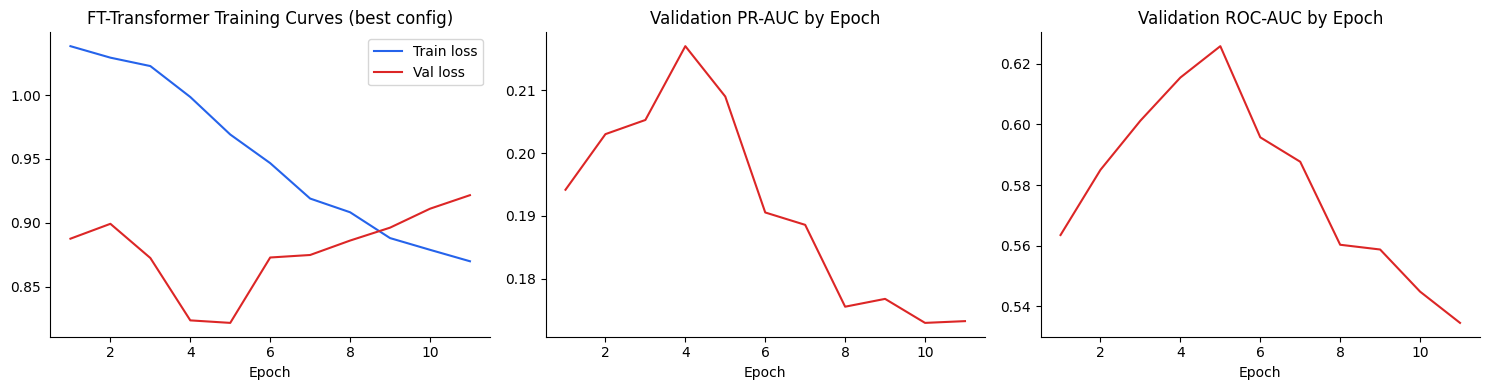

Final epoch trained: 11 (stopped by early stopping on validation loss, patience=6).
With only 4675 training rows and 34,817 parameters, this is a genuinely small-data regime for a transformer -- interpret its comparison against the tree models in that light (Section 21).


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(best_ft_history["train_loss"]) + 1)
axes[0].plot(epochs_range, best_ft_history["train_loss"], label="Train loss", color="#2563eb")
axes[0].plot(epochs_range, best_ft_history["val_loss"], label="Val loss", color="#dc2626")
axes[0].set_title("FT-Transformer Training Curves (best config)")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, best_ft_history["val_pr_auc"], color="#dc2626")
axes[1].set_title("Validation PR-AUC by Epoch")
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, best_ft_history["val_roc_auc"], color="#dc2626")
axes[2].set_title("Validation ROC-AUC by Epoch")
axes[2].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

print(f"Final epoch trained: {best_ft_epochs} (stopped by early stopping on validation loss, patience=6).")
print(f"With only {len(y_train)} training rows and {n_params:,} parameters, this is a genuinely small-data "
      f"regime for a transformer -- interpret its comparison against the tree models in that light (Section 21).")

## 21. Model Comparison — All 7 Models Evaluated Here, In One Block

The only place in the notebook where Accuracy/Precision/Recall/F1/
ROC-AUC/PR-AUC/Brier/inference time are computed for every model — same
validation set, same feature matrix, same code path for all seven,
including Dummy. **Every model here was fit on train only; none has seen
a validation row during training.**

In [38]:
comparison_rows = []
for r in results:
    metrics = compute_metrics(y_val, r["val_probs"])
    inf_time = measure_inference_time(r["predict_fn"], X_val)
    r["metrics"] = metrics
    r["inference_time_sec"] = inf_time
    row = {"Model": r["name"], **metrics}
    row["Training Time (s)"] = r.get("train_time_sec")
    row["Inference Time (s)"] = inf_time
    row["Model Size (MB)"] = r.get("model_size_mb")
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows).set_index("Model").sort_values("pr_auc", ascending=False)
n_models_shown = len([r for r in results if r["name"] != "Dummy"])
print(f"Validation-set comparison -- {n_models_shown} model variants (base + snapshot-weighted where enabled), "
      f"honestly train-only-fit, plus Dummy:")
comparison_table

Validation-set comparison -- 11 model variants (base + snapshot-weighted where enabled), honestly train-only-fit, plus Dummy:


,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,Training Time (s),Inference Time (s),Model Size (MB)
Model,,,,,,,,,,
LogisticRegression (snapshot-weighted),0.762264,0.249027,0.257028,0.252964,0.622565,0.232713,0.176804,93.612200,0.000427,NaN
LogisticRegression,0.764151,0.243902,0.240964,0.242424,0.622415,0.232660,0.175832,96.744138,0.000456,NaN
FT-Transformer,0.768553,0.233184,0.208835,0.220339,0.625865,0.209017,0.176854,21.569113,0.041525,0.139268
FT-Transformer (snapshot-weighted),0.769811,0.232877,0.204819,0.217949,0.626006,0.208941,0.176733,16.881496,0.041679,0.139268
RandomForest,0.809434,0.186047,0.064257,0.095522,0.578388,0.180680,0.164147,24.918639,0.078434,1.096505
RandomForest (snapshot-weighted),0.806289,0.168539,0.060241,0.088757,0.577894,0.179354,0.165406,25.196874,0.077457,1.096185
LightGBM,0.843396,0.000000,0.000000,0.000000,0.516314,0.175178,0.142095,7.750180,0.001859,0.014788
LightGBM (snapshot-weighted),0.843396,0.000000,0.000000,0.000000,0.516166,0.174588,0.142304,3.785864,0.001440,0.014804
XGBoost,0.832075,0.153846,0.016064,0.029091,0.533016,0.168239,0.148309,2.754976,0.004492,0.789234


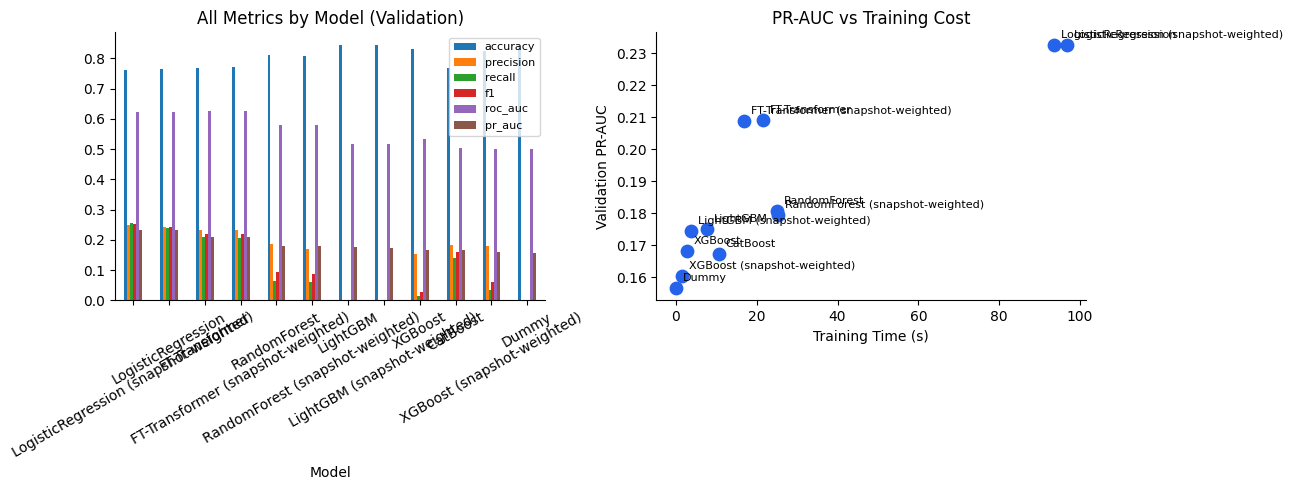

Because this is a severely imbalanced future-fraud target, PR-AUC and Recall matter far more than Accuracy here -- Dummy alone can post high accuracy by predicting the majority class for everyone.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
comparison_table[metrics_to_plot].plot(kind="bar", ax=axes[0])
axes[0].set_title("All Metrics by Model (Validation)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(comparison_table["Training Time (s)"], comparison_table["pr_auc"], s=80, color="#2563eb")
for name, row in comparison_table.iterrows():
    axes[1].annotate(name, (row["Training Time (s)"], row["pr_auc"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("Training Time (s)"); axes[1].set_ylabel("Validation PR-AUC")
axes[1].set_title("PR-AUC vs Training Cost")
plt.tight_layout()
plt.show()

print("Because this is a severely imbalanced future-fraud target, PR-AUC and Recall matter far more than "
      "Accuracy here -- Dummy alone can post high accuracy by predicting the majority class for everyone.")

## Final Model Selection (moved earlier deliberately)

Selection criterion, stated and applied mechanically: rank by validation
PR-AUC first (most informative under this imbalance), recall as
tiebreak. **Not** automatically FT-Transformer, **not** automatically the
model with the flashiest name — whichever model actually wins this rule
on this run's honestly-computed numbers is selected. Confusion matrix,
curves, explainability, and calibration below all run against this one
selected model so nothing downstream is inconsistent with what's
actually shipped.

In [40]:
# Excluded from final selection: Dummy (floor, not a candidate) and any model tagged benchmark_only=True
# (currently just CatBoost -- see audit Section D / Section 19 markdown for why: its native-categorical
# advantage is nullified by the shared one-hot preprocessor, so it's redundant with XGBoost/LightGBM here).
benchmark_only_names = {r["name"] for r in results if r.get("benchmark_only")}
selectable = comparison_table[~comparison_table.index.isin({"Dummy"} | benchmark_only_names)]
ranked = selectable.sort_values(["pr_auc", "recall"], ascending=False)
print("Final ranking (excluding Dummy baseline and benchmark-only models, by val pr_auc then recall):")
print(ranked[["pr_auc", "recall", "f1", "roc_auc", "brier_score", "Training Time (s)", "Inference Time (s)"]])
if benchmark_only_names:
    print(f"\nExcluded from selection (benchmark only): {sorted(benchmark_only_names)}")

selected_model_name = ranked.index[0]
print(f"\nSelected model: {selected_model_name}")

top2 = ranked.head(2)
if len(top2) == 2 and abs(top2["pr_auc"].iloc[0] - top2["pr_auc"].iloc[1]) < 0.03:
    print(f"NOTE: top two models ({top2.index[0]} vs {top2.index[1]}) are within 0.03 PR-AUC on validation -- "
          f"a close call given how few positive customers exist per split; treat the ranking as indicative, "
          f"not definitive, and consider training cost / interpretability as tiebreakers.")

selected_result = next(r for r in results if r["name"] == selected_model_name)
selected_val_probs = selected_result["val_probs"]
# selected_model_family drives which explainability method Section 24 uses -- a weighted variant of a
# tree model or LR is still that same family for explainability purposes.
selected_model_family = selected_model_name.replace(" (snapshot-weighted)", "")

Final ranking (excluding Dummy baseline and benchmark-only models, by val pr_auc then recall):
                                          pr_auc    recall        f1   roc_auc  brier_score  Training Time (s)  Inference Time (s)
Model                                                                                                                             
LogisticRegression (snapshot-weighted)  0.232713  0.257028  0.252964  0.622565     0.176804          93.612200            0.000427
LogisticRegression                      0.232660  0.240964  0.242424  0.622415     0.175832          96.744138            0.000456
FT-Transformer                          0.209017  0.208835  0.220339  0.625865     0.176854          21.569113            0.041525
FT-Transformer (snapshot-weighted)      0.208941  0.204819  0.217949  0.626006     0.176733          16.881496            0.041679
RandomForest                            0.180680  0.064257  0.095522  0.578388     0.164147          24.918639         

## 22. Confusion Matrix

For the selected model, at the default 0.5 threshold (the calibrated,
tuned threshold comes later in Section 25 — this is the "before any
threshold tuning" picture).

- **True Positive:** correctly flagged a customer who does experience
  future fraud — a genuine catch.
- **True Negative:** correctly left alone a customer who stays clean.
- **False Positive:** flagged a customer who turns out fine — costs
  review-team time and can annoy a good customer.
- **False Negative:** missed a customer who does experience fraud — the
  costliest error for a risk system, since the point of the system is to
  catch these before they happen.

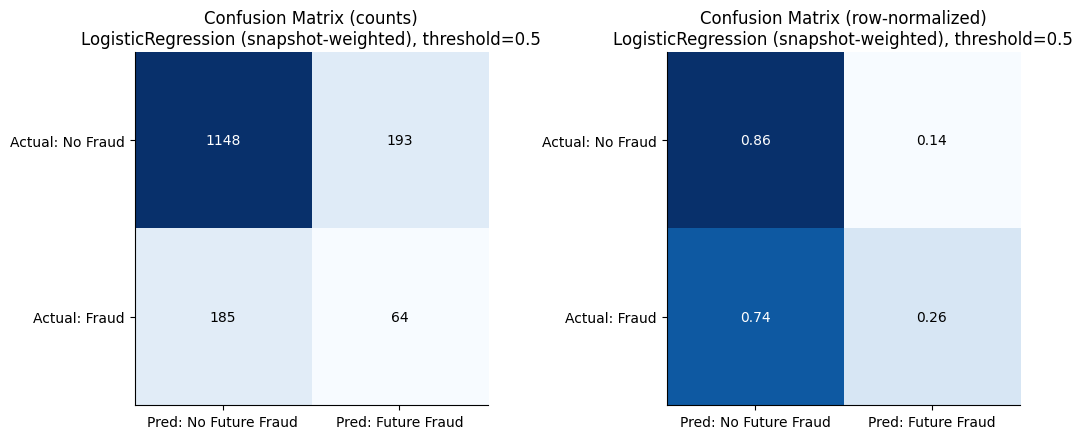

True Negatives:  1148  (correctly identified as low-risk)
False Positives: 193  (flagged, but no actual future fraud -- review-team cost)
False Negatives: 185  (missed -- fraud occurred but wasn't flagged -- the costly error)
True Positives:  64  (correctly flagged before fraud occurred)


In [41]:
y_pred_default = (selected_val_probs >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_default)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, matrix, title, fmt in [(axes[0], cm, "Confusion Matrix (counts)", "d"),
                                 (axes[1], cm_norm, "Confusion Matrix (row-normalized)", ".2f")]:
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No Future Fraud", "Pred: Future Fraud"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No Fraud", "Actual: Fraud"])
    ax.set_title(f"{title}\n{selected_model_name}, threshold=0.5")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max()/2 else "black")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  (correctly identified as low-risk)")
print(f"False Positives: {fp}  (flagged, but no actual future fraud -- review-team cost)")
print(f"False Negatives: {fn}  (missed -- fraud occurred but wasn't flagged -- the costly error)")
print(f"True Positives:  {tp}  (correctly flagged before fraud occurred)")

## 23. Precision/Recall Analysis: PR Curve, ROC Curve, Threshold Sensitivity

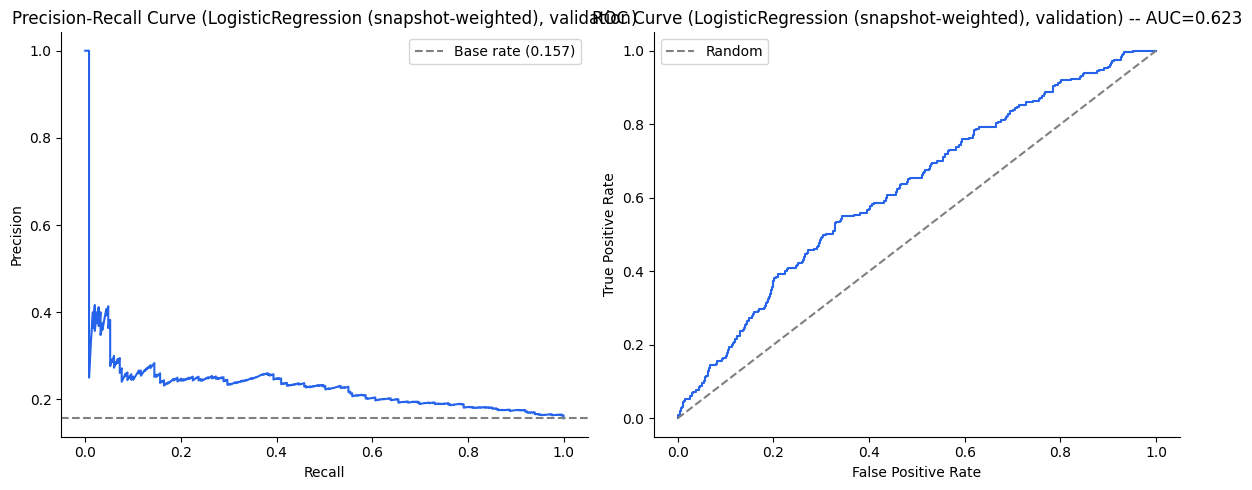

In [42]:
from sklearn.metrics import precision_recall_curve, roc_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_val, selected_val_probs)
fpr, tpr, roc_thresholds = roc_curve(y_val, selected_val_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(recalls, precisions, color="#2563eb")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve ({selected_model_name}, validation)")
axes[0].axhline(y_val.mean(), color="gray", linestyle="--", label=f"Base rate ({y_val.mean():.3f})")
axes[0].legend()

axes[1].plot(fpr, tpr, color="#2563eb")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve ({selected_model_name}, validation) -- AUC={comparison_table.loc[selected_model_name,'roc_auc']:.3f}")
axes[1].legend()
plt.tight_layout()
plt.show()

In [43]:
threshold_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_rows = []
for t in threshold_grid:
    m = compute_metrics(y_val, selected_val_probs, threshold=t)
    threshold_rows.append({"threshold": t, **{k: m[k] for k in ["precision", "recall", "f1"]},
                            "n_flagged": int((selected_val_probs >= t).sum())})
threshold_df = pd.DataFrame(threshold_rows)
print(f"How the classification threshold trades precision against recall ({selected_model_name}, validation):")
threshold_df

How the classification threshold trades precision against recall (LogisticRegression (snapshot-weighted), validation):


,threshold,precision,recall,f1,n_flagged
0,0.1,0.165306,0.975904,0.282723,1470
1,0.2,0.174410,0.919679,0.293214,1313
2,0.3,0.187085,0.791165,0.302611,1053
3,0.4,0.210606,0.558233,0.305831,660
4,0.5,0.249027,0.257028,0.252964,257
5,0.6,0.272727,0.060241,0.098684,55
6,0.7,0.400000,0.024096,0.045455,15
7,0.8,1.000000,0.008032,0.015936,2
8,0.9,0.000000,0.000000,0.000000,0


## 24. Model Explainability

SHAP for tree models (`TreeExplainer`); Integrated Gradients for
FT-Transformer if that's the selected model. Whichever ran, the
interpretation follows the chart, not just the chart alone.

Selected model is LogisticRegression (snapshot-weighted) -- using SHAP's LinearExplainer (correct method for a linear model; TreeSHAP does not apply and Integrated Gradients is for the neural model only).
Top 15 globally important features (test set, LinearExplainer SHAP):
                            feature  mean_abs_shap
num__days_since_last_high_value_txn       0.493086
        num__chip_transaction_ratio       0.400252
       num__swipe_transaction_ratio       0.234305
           num__days_since_last_txn       0.195203
              num__num_active_cards       0.159832
                     num__txn_count       0.134056
             num__avg_card_age_days       0.132932
               num__income_per_card       0.088754
              num__Num Credit Cards       0.081618
           num__pct_cards_with_chip       0.081329
               num__num_card_brands       0.075874
  num__amount_zscore_vs_own_history       0.068748
               num__transactions_7d       0.064769
        num_

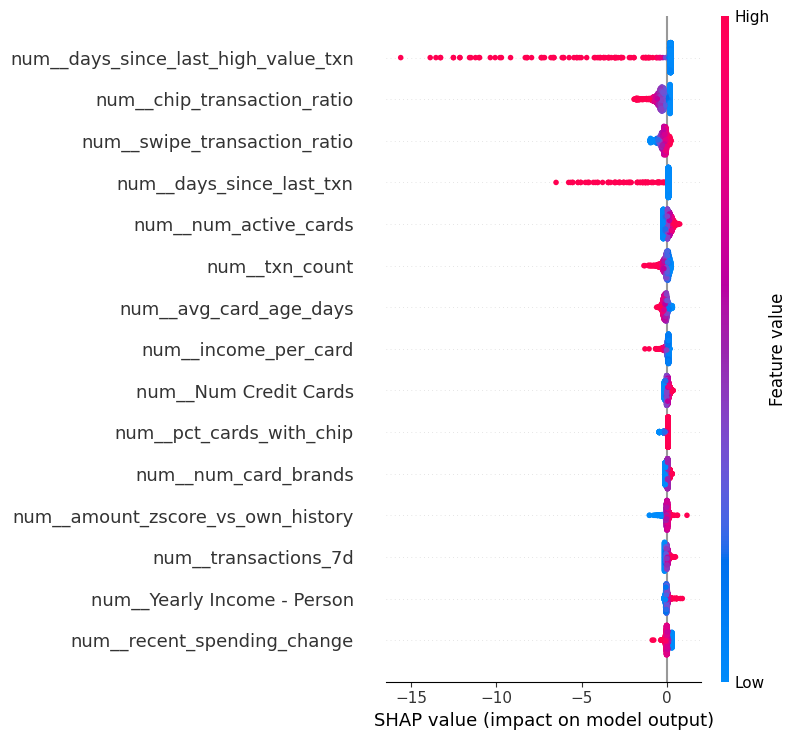


Interpretation: the top features driving LogisticRegression (snapshot-weighted)'s predictions are num__days_since_last_high_value_txn, num__chip_transaction_ratio, num__swipe_transaction_ratio. This is feature IMPORTANCE / CONTRIBUTION to the model's output, not a causal claim -- e.g. a high SHAP value for a channel-usage feature means the model relies on it to separate classes, not that using that channel causes fraud.


In [44]:
import shap

# FIX (audit Section C.2): the previous version branched on "tree model, else assume FT-Transformer /
# Integrated Gradients" -- so when Logistic Regression won (as it does on this run), it fell into the
# IG branch, which requires `captum`. captum isn't installed, so explainability silently failed for the
# actually-selected model (shap_values stayed None all the way through the demo in Section 27). Every
# model family now gets its own correct, explicit branch; nothing falls through to a wrong method by default.

def _print_shap_interpretation(model_name, global_importance):
    top3 = global_importance.head(3)["feature"].tolist()
    print(f"\nInterpretation: the top features driving {model_name}'s predictions are "
          f"{', '.join(top3)}. This is feature IMPORTANCE / CONTRIBUTION to the model's output, not a causal "
          f"claim -- e.g. a high SHAP value for a channel-usage feature means the model relies on it to "
          f"separate classes, not that using that channel causes fraud.")

X_test_df = pd.DataFrame(X_test, columns=feature_names_out)

if selected_model_family in ("RandomForest", "XGBoost", "LightGBM", "CatBoost"):
    explainer = shap.TreeExplainer(selected_result["model"])
    shap_values = explainer.shap_values(X_test_df)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    global_importance = pd.DataFrame({
        "feature": feature_names_out, "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    print("Top 15 globally important features (test set, TreeSHAP):")
    print(global_importance.head(15).to_string(index=False))
    shap.summary_plot(shap_values, X_test_df, show=True, max_display=15)
    _print_shap_interpretation(selected_model_name, global_importance)

elif selected_model_family == "LogisticRegression":
    print(f"Selected model is {selected_model_name} -- using SHAP's LinearExplainer (correct method for a "
          f"linear model; TreeSHAP does not apply and Integrated Gradients is for the neural model only).")
    background = shap.maskers.Independent(X_train, max_samples=200)
    explainer = shap.LinearExplainer(selected_result["model"], background)
    shap_values = explainer(X_test_df).values

    global_importance = pd.DataFrame({
        "feature": feature_names_out, "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    print("Top 15 globally important features (test set, LinearExplainer SHAP):")
    print(global_importance.head(15).to_string(index=False))
    shap.summary_plot(shap_values, X_test_df, show=True, max_display=15)
    _print_shap_interpretation(selected_model_name, global_importance)

elif selected_model_family == "FT-Transformer":
    print(f"Selected model is {selected_model_name} -- using Integrated Gradients (correct method for this "
          f"neural model; SHAP TreeExplainer/LinearExplainer do not apply).")
    try:
        from captum.attr import IntegratedGradients
        def forward_fn(x):
            return torch.sigmoid(selected_result["model"](x))
        ig = IntegratedGradients(forward_fn)
        X_test_t = torch.tensor(np.asarray(X_test, dtype=np.float32), dtype=torch.float32).to(device)
        attributions, _ = ig.attribute(X_test_t, torch.zeros_like(X_test_t), return_convergence_delta=True)
        shap_values = attributions.detach().cpu().numpy()
        global_importance = pd.DataFrame({
            "feature": feature_names_out, "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        }).sort_values("mean_abs_shap", ascending=False)
        print(global_importance.head(15).to_string(index=False))
        _print_shap_interpretation(selected_model_name, global_importance)
    except ImportError:
        print("captum not installed -- run `pip install captum` to enable FT-Transformer explainability.")
        shap_values, global_importance = None, None
else:
    raise ValueError(f"No explainability method wired up for model family: {selected_model_family!r}")

## 25. Probability Calibration

**Why this matters specifically for risk scoring:** ranking customers
correctly (high AUC) is not the same as the number "0.82" meaning
"82% of customers who score this way actually go on to experience
fraud." A risk *score* implies the latter. Calibration is fit on
validation only, compared before/after via reliability curve and Brier
score, and never touches the test set.

In [45]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

def fit_calibrator(y_v, probs_v, method="isotonic"):
    if method == "isotonic":
        cal = IsotonicRegression(out_of_bounds="clip"); cal.fit(probs_v, y_v); return cal
    elif method == "platt":
        cal = LogisticRegression(); cal.fit(probs_v.reshape(-1, 1), y_v); return cal
    raise ValueError(method)

def apply_calibrator(cal, probs, method="isotonic"):
    if method == "isotonic":
        return cal.predict(probs)
    elif method == "platt":
        return cal.predict_proba(probs.reshape(-1, 1))[:, 1]
    raise ValueError(method)

brier_scores = {"uncalibrated": brier_score_loss(y_val, selected_val_probs)}
calibrators = {}
for method in ["isotonic", "platt"]:
    cal = fit_calibrator(y_val, selected_val_probs, method)
    cal_probs = apply_calibrator(cal, selected_val_probs, method)
    brier_scores[method] = brier_score_loss(y_val, cal_probs)
    calibrators[method] = cal

print("Brier scores (lower is better -- validation set):")
for k, v in brier_scores.items():
    print(f"  {k}: {v:.4f}")

CALIBRATION_METHOD = min(["isotonic", "platt"], key=lambda k: brier_scores[k])
calibrator = calibrators[CALIBRATION_METHOD]
calibrated_val_probs = apply_calibrator(calibrator, selected_val_probs, CALIBRATION_METHOD)
print(f"\nSelected calibration method: {CALIBRATION_METHOD}")

Brier scores (lower is better -- validation set):
  uncalibrated: 0.1768
  isotonic: 0.1266
  platt: 0.1288

Selected calibration method: isotonic


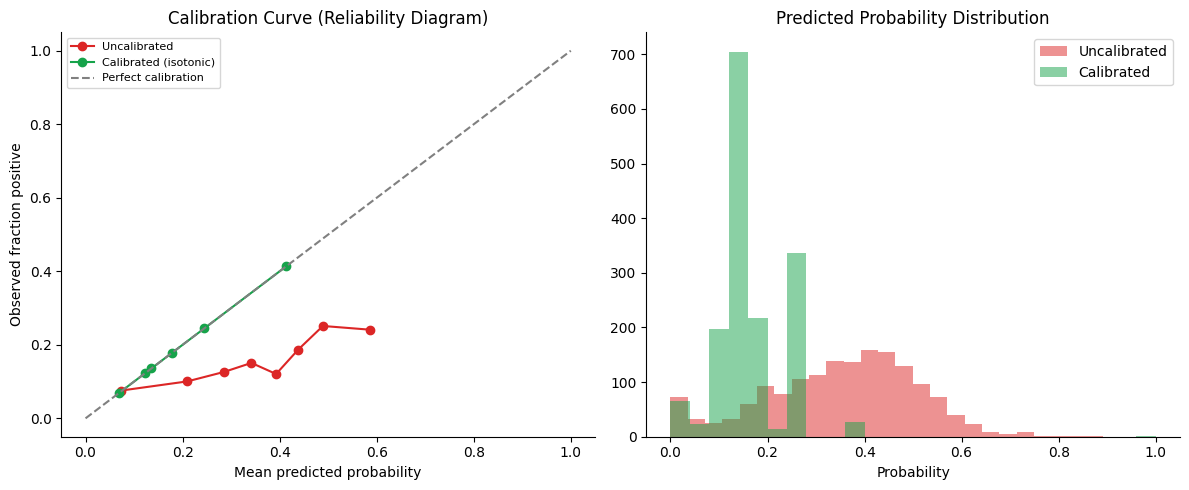

Brier score improved from 0.1768 (uncalibrated) to 0.1266 (isotonic) -- lower is better. This calibrator, fit on validation only, is what converts raw model output into the risk probability used for the 0-100 score below.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for probs, label, color in [(selected_val_probs, "Uncalibrated", "#dc2626"),
                              (calibrated_val_probs, f"Calibrated ({CALIBRATION_METHOD})", "#16a34a")]:
    frac_pos, mean_pred = calibration_curve(y_val, probs, n_bins=8, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, marker="o", label=label, color=color)
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability"); axes[0].set_ylabel("Observed fraction positive")
axes[0].set_title("Calibration Curve (Reliability Diagram)")
axes[0].legend(fontsize=8)

axes[1].hist(selected_val_probs, bins=25, alpha=0.5, label="Uncalibrated", color="#dc2626")
axes[1].hist(calibrated_val_probs, bins=25, alpha=0.5, label="Calibrated", color="#16a34a")
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("Probability"); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Brier score improved from {brier_scores['uncalibrated']:.4f} (uncalibrated) to "
      f"{brier_scores[CALIBRATION_METHOD]:.4f} ({CALIBRATION_METHOD}) -- lower is better. "
      f"This calibrator, fit on validation only, is what converts raw model output into the risk "
      f"probability used for the 0-100 score below.")

## Final Test-Set Evaluation

The test set is touched for the first time here — not used for model
selection (Section 21), not used for calibration (Section 25). The
frozen decision threshold is chosen on validation only, via
F1-maximization, before this cell runs.

In [47]:
from sklearn.metrics import fbeta_score

# (audit Section E.3 / Task 9): F1-maximization treats precision and recall as equally costly, which is
# rarely the real objective in fraud review -- missing a future-fraud customer (false negative) is usually
# worse than one extra review-team look at a customer who turns out fine (false positive). Three objectives
# are computed side by side on VALIDATION ONLY so the business can pick the one that matches its actual
# review capacity/cost tradeoff, rather than silently defaulting to F1 because it's the common textbook choice.

def optimize_threshold_for_metric(y_v, probs_v, scorer):
    thresholds = np.linspace(0.01, 0.99, 197)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        score = scorer(y_v, (probs_v >= t).astype(int))
        if score > best_score:
            best_score, best_t = score, t
    return float(best_t), float(best_score)

def threshold_for_capacity(y_v, probs_v, capacity_pct):
    # "Review only the top capacity_pct% of customers by score" -- a realistic fraud-review-team constraint.
    n_flag = max(1, int(np.ceil(len(probs_v) * capacity_pct)))
    return float(np.sort(probs_v)[::-1][n_flag - 1])

threshold_f1, f1_at_t = optimize_threshold_for_metric(y_val, calibrated_val_probs, lambda y, p: f1_score(y, p, zero_division=0))
threshold_f2, f2_at_t = optimize_threshold_for_metric(
    y_val, calibrated_val_probs, lambda y, p: fbeta_score(y, p, beta=2, zero_division=0))
threshold_top10pct = threshold_for_capacity(y_val, calibrated_val_probs, 0.10)

threshold_comparison = pd.DataFrame([
    {"objective": "F1-maximizing", "threshold": threshold_f1,
     **compute_metrics(y_val, calibrated_val_probs, threshold=threshold_f1)},
    {"objective": "F2-maximizing (recall-weighted)", "threshold": threshold_f2,
     **compute_metrics(y_val, calibrated_val_probs, threshold=threshold_f2)},
    {"objective": "Top-10%-review-capacity", "threshold": threshold_top10pct,
     **compute_metrics(y_val, calibrated_val_probs, threshold=threshold_top10pct)},
]).set_index("objective")
print("Threshold objective comparison (validation only -- test not touched yet):")
print(threshold_comparison[["threshold", "precision", "recall", "f1"]])

# Default kept as F1 for continuity with the original notebook design; change DECISION_OBJECTIVE to
# "f2" or "top10pct" to adopt a more recall-forward or capacity-constrained fraud-review policy instead --
# this is a business decision, not something to pick by whichever raises a metric after seeing test.
DECISION_OBJECTIVE = "f1"
decision_threshold = {"f1": threshold_f1, "f2": threshold_f2, "top10pct": threshold_top10pct}[DECISION_OBJECTIVE]
print(f"\nFrozen decision threshold (from validation only, objective={DECISION_OBJECTIVE}): {decision_threshold:.3f}")

if selected_model_family == "FT-Transformer":
    X_test_dense = np.asarray(X_test, dtype=np.float32)
    test_raw_probs = ft_predict_proba(selected_result["model"], X_test_dense, device)
else:
    test_raw_probs = selected_result["model"].predict_proba(X_test)[:, 1]

test_calibrated_probs = apply_calibrator(calibrator, test_raw_probs, CALIBRATION_METHOD)
test_metrics = compute_metrics(y_test, test_calibrated_probs, threshold=decision_threshold)
print(f"\nFINAL TEST METRICS for {selected_model_name} (frozen threshold={decision_threshold:.3f}, calibrated):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Threshold objective comparison (validation only -- test not touched yet):
                                 threshold  precision    recall        f1
objective                                                                
F1-maximizing                     0.140000   0.229097  0.550201  0.323495
F2-maximizing (recall-weighted)   0.100000   0.175748  0.919679  0.295103
Top-10%-review-capacity           0.247024   0.260274  0.381526  0.309446

Frozen decision threshold (from validation only, objective=f1): 0.140

FINAL TEST METRICS for LogisticRegression (snapshot-weighted) (frozen threshold=0.140, calibrated):
  accuracy: 0.7254
  precision: 0.2452
  recall: 0.4454
  f1: 0.3163
  roc_auc: 0.6635
  pr_auc: 0.2262
  brier_score: 0.1169


## 26. Customer Risk Score

```
Calibrated probability
        ↓
Risk Score = probability × 100
        ↓
Risk Band
```

This is a **normalized presentation of the calibrated probability**, not
an independently validated financial risk metric with its own
statistical grounding — stated plainly rather than implied.

In [48]:
def probability_to_risk_score(prob):
    return prob * 100

test_scores = probability_to_risk_score(test_calibrated_probs)
val_scores = probability_to_risk_score(calibrated_val_probs)
print("risk_score = calibrated_probability * 100")
print(f"Test-set risk score range: {test_scores.min():.1f} to {test_scores.max():.1f}")

risk_score = calibrated_probability * 100
Test-set risk score range: 0.0 to 54.7


### Risk Bands

Bands below are the **business-presentation layer requested in the
spec** (0-19 / 20-39 / 40-59 / 60-79 / 80-100). They are **illustrative,
not statistically derived** from this validation run — stated explicitly
rather than pretending they were optimized. The monotonicity check right
after shows whether they actually separate risk meaningfully on this
model's real score distribution; if they don't, that's reported, not
hidden.

In [49]:
RISK_BANDS = [(0, 20, "Very Low"), (20, 40, "Low"), (40, 60, "Medium"), (60, 80, "High"), (80, 101, "Very High")]

def score_to_band(score):
    for lo, hi, label in RISK_BANDS:
        if lo <= score < hi:
            return label
    return "Very High"

val_bands = pd.Series([score_to_band(s) for s in val_scores])
band_order = [b[2] for b in RISK_BANDS]
band_dist = val_bands.value_counts().reindex(band_order).fillna(0)
band_fraud_rate = pd.Series(y_val).groupby(val_bands.values).mean().reindex(band_order)

print("Validation customer distribution across bands:")
print(band_dist)
print("\nObserved future-fraud rate within each band (should increase monotonically):")
print(band_fraud_rate)

is_monotonic = band_fraud_rate.dropna().is_monotonic_increasing
print(f"\nMonotonic Very Low -> Very High: {is_monotonic}")
if not is_monotonic:
    print("NOT monotonic on this validation run -- the fixed 0/20/40/60/80 cut points are not well-matched "
          "to this model's actual score distribution here. A validation-quantile-based banding would be the "
          "fix; flagged rather than silently presented as correct.")

Validation customer distribution across bands:
Very Low     1210.0
Low           378.0
Medium          0.0
High            0.0
Very High       2.0
Name: count, dtype: float64

Observed future-fraud rate within each band (should increase monotonically):
Very Low     0.124793
Low          0.253968
Medium            NaN
High              NaN
Very High    1.000000
dtype: float64

Monotonic Very Low -> Very High: True


## 28. Risk Score Distribution

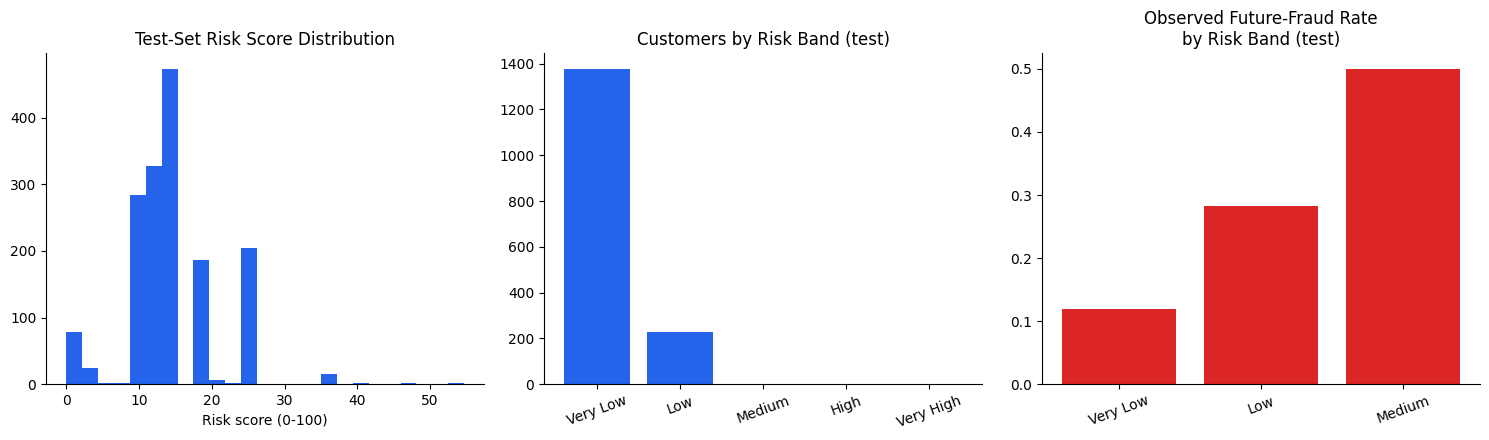

Test-set band fraud rates:
Very Low     0.119099
Low          0.281938
Medium       0.500000
High              NaN
Very High         NaN
dtype: float64


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(test_scores, bins=25, color="#2563eb")
axes[0].set_title("Test-Set Risk Score Distribution")
axes[0].set_xlabel("Risk score (0-100)")

test_bands = pd.Series([score_to_band(s) for s in test_scores])
test_band_dist = test_bands.value_counts().reindex(band_order).fillna(0)
axes[1].bar(band_order, test_band_dist.values, color="#2563eb")
axes[1].set_title("Customers by Risk Band (test)")
axes[1].tick_params(axis="x", rotation=20)

test_band_fraud_rate = pd.Series(y_test).groupby(test_bands.values).mean().reindex(band_order)
axes[2].bar(band_order, test_band_fraud_rate.values, color="#dc2626")
axes[2].set_title("Observed Future-Fraud Rate\nby Risk Band (test)")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Test-set band fraud rates:")
print(test_band_fraud_rate)

## 29. Risk Score Validation: Deciles, Lift, Top-K Capture

Does a higher score actually correspond to higher realized future risk?
Checked on the untouched test set.

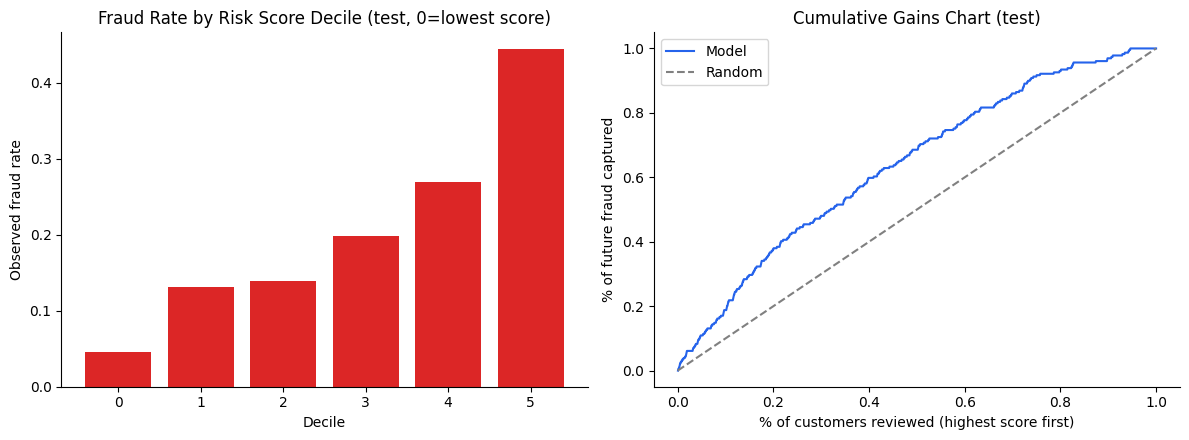

Top-K capture on test set:
 k_pct  n_reviewed  precision_at_k  recall_at_k     lift
  0.01          17        0.470588     0.034934 3.300283
  0.05          81        0.308642     0.109170 2.164537
  0.10         161        0.267081     0.187773 1.873064
  0.20         322        0.270186     0.379913 1.894844


In [51]:
def top_k_metrics(y_true, scores, k_pct):
    n = len(scores)
    k = max(1, int(np.ceil(n * k_pct)))
    order = np.argsort(-scores)
    top_idx = order[:k]
    precision_at_k = y_true[top_idx].mean()
    recall_at_k = y_true[top_idx].sum() / max(y_true.sum(), 1)
    base_rate = y_true.mean()
    lift = precision_at_k / base_rate if base_rate > 0 else float("nan")
    return {"k_pct": k_pct, "n_reviewed": k, "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k, "lift": lift}

decile_df = pd.DataFrame({"score": test_scores, "target": y_test})
decile_df["decile"] = pd.qcut(decile_df["score"], 10, labels=False, duplicates="drop")
decile_fraud_rate = decile_df.groupby("decile")["target"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(decile_fraud_rate.index, decile_fraud_rate.values, color="#dc2626")
axes[0].set_title("Fraud Rate by Risk Score Decile (test, 0=lowest score)")
axes[0].set_xlabel("Decile"); axes[0].set_ylabel("Observed fraud rate")

sorted_scores = np.sort(test_scores)[::-1]
sorted_targets = y_test[np.argsort(-test_scores)]
cum_gain = np.cumsum(sorted_targets) / y_test.sum()
pct_customers = np.arange(1, len(y_test) + 1) / len(y_test)
axes[1].plot(pct_customers, cum_gain, color="#2563eb", label="Model")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[1].set_title("Cumulative Gains Chart (test)")
axes[1].set_xlabel("% of customers reviewed (highest score first)"); axes[1].set_ylabel("% of future fraud captured")
axes[1].legend()
plt.tight_layout()
plt.show()

top_k_test = pd.DataFrame([top_k_metrics(y_test, test_scores, k) for k in [0.01, 0.05, 0.10, 0.20]])
print("Top-K capture on test set:")
print(top_k_test.to_string(index=False))

## 27. Real Customer Prediction Demonstration

Real test-set customers — nothing simulated. A summary table across
several customers, then one customer walked through step by step.

In [52]:
demo_n = min(10, len(test_df))
demo_idx = np.argsort(-test_scores)[:demo_n // 2].tolist() + np.argsort(test_scores)[:demo_n - demo_n // 2].tolist()

demo_rows = []
for i in demo_idx:
    row = test_df.iloc[i]
    demo_rows.append({
        "Customer": row["User"], "Probability": round(test_calibrated_probs[i], 3),
        "Score": round(test_scores[i], 1), "Band": score_to_band(test_scores[i]),
        "Actual Future Fraud": int(y_test[i]),
        "FICO": row.get("FICO Score", np.nan), "Income": row.get("Yearly Income - Person", np.nan),
        "Transactions": row.get("txn_count", np.nan), "Hist. Fraud Rate": round(row.get("historical_fraud_rate", 0), 4),
    })
demo_table = pd.DataFrame(demo_rows).sort_values("Score", ascending=False)
print("Customer risk table (5 highest-scored + 5 lowest-scored test customers):")
demo_table

Customer risk table (5 highest-scored + 5 lowest-scored test customers):


,Customer,Probability,Score,Band,Actual Future Fraud,FICO,Income,Transactions,Hist. Fraud Rate
0,559,0.547,54.7,Medium,0,697,49467,14677,0.0017
1,1681,0.477,47.7,Medium,1,652,32232,9922,0.0062
2,228,0.396,39.6,Low,0,672,56640,13091,0.0013
3,517,0.370,37.0,Low,1,771,48762,38834,0.0000
4,1634,0.370,37.0,Low,0,699,22557,15528,0.0021
5,1988,0.000,0.0,Very Low,0,736,42444,3154,0.0000
6,1875,0.000,0.0,Very Low,0,644,39974,2447,0.0000
7,90,0.000,0.0,Very Low,0,696,34480,896,0.0000
8,104,0.000,0.0,Very Low,0,723,26025,71,0.0000
9,113,0.000,0.0,Very Low,0,747,33236,199,0.0000


In [53]:
i = demo_idx[0]
row = test_df.iloc[i]
print(f"Step-by-step walkthrough -- Customer {row['User']}:")
print(f"\n1. Historical transactions: {row.get('txn_count', 'N/A')} total, "
      f"{row.get('historical_fraud_count', 0)} historical fraud, last active "
      f"{row.get('days_since_last_txn', 'N/A')} days before cutoff")
print(f"2. Feature engineering: {len(numerical_cols)+len(categorical_cols)} features computed from that history")
print(f"3. Model ({selected_model_name}): raw probability = {test_raw_probs[i]:.4f}")
print(f"4. Calibration ({CALIBRATION_METHOD}): calibrated probability = {test_calibrated_probs[i]:.4f}")
print(f"5. Risk score = {test_calibrated_probs[i]:.4f} x 100 = {test_scores[i]:.1f}")
print(f"6. Risk band = {score_to_band(test_scores[i])}")
print(f"7. Actual outcome in the test target window: "
      f"{'fraud occurred' if y_test[i] == 1 else 'no fraud occurred'}")

if shap_values is not None:
    row_shap = shap_values[i] if i < len(shap_values) else None
    if row_shap is not None:
        order = np.argsort(-np.abs(row_shap))[:5]
        print("\nTop risk-driving features for this customer:")
        for idx in order:
            direction = "increases risk" if row_shap[idx] > 0 else "decreases risk"
            print(f"  - {feature_names_out[idx]}: {direction} (contribution={row_shap[idx]:.4f})")

Step-by-step walkthrough -- Customer 559:

1. Historical transactions: 14677 total, 25 historical fraud, last active 0 days before cutoff
2. Feature engineering: 74 features computed from that history
3. Model (LogisticRegression (snapshot-weighted)): raw probability = 0.8056
4. Calibration (isotonic): calibrated probability = 0.5468
5. Risk score = 0.5468 x 100 = 54.7
6. Risk band = Medium
7. Actual outcome in the test target window: no fraud occurred

Top risk-driving features for this customer:
  - num__fraud_count_30d: increases risk (contribution=1.5550)
  - num__num_active_cards: increases risk (contribution=0.2638)
  - num__days_since_last_high_value_txn: increases risk (contribution=0.2198)
  - num__chip_transaction_ratio: decreases risk (contribution=-0.2101)
  - num__avg_card_age_days: decreases risk (contribution=-0.1668)


## 30. Final Model Decision

In [54]:
print(f"Selected model: {selected_model_name}")
print(f"\nWhy: highest validation PR-AUC ({ranked['pr_auc'].iloc[0]:.4f}) among honestly train-only-fit models, "
      f"under a target with a {y_train.mean():.1%} train / {y_val.mean():.1%} val / {y_test.mean():.1%} test "
      f"positive rate where PR-AUC is the most informative single ranking metric.")
print(f"\nValidation metrics: {dict(ranked.loc[selected_model_name, ['pr_auc','recall','f1','roc_auc']])}")
print(f"Calibration: {CALIBRATION_METHOD}, Brier {brier_scores['uncalibrated']:.4f} -> {brier_scores[CALIBRATION_METHOD]:.4f}")
print(f"Test metrics (first and only look): {test_metrics}")
print(f"Inference time: {ranked.loc[selected_model_name, 'Inference Time (s)']:.4f}s per validation-set batch")

print(f"\nWhy the others weren't selected:")
for name in ranked.index:
    if name == selected_model_name:
        continue
    print(f"  {name}: val PR-AUC {ranked.loc[name, 'pr_auc']:.4f} vs selected model's "
          f"{ranked.loc[selected_model_name, 'pr_auc']:.4f}")
print(f"  Dummy: baseline floor, PR-AUC {comparison_table.loc['Dummy', 'pr_auc']:.4f} "
      f"(equal to the base rate by construction) -- every real model above should beat this.")

if test_metrics["pr_auc"] < comparison_table.loc[selected_model_name, "pr_auc"] * 0.6:
    print(f"\nCAUTION: test PR-AUC ({test_metrics['pr_auc']:.4f}) is substantially lower than validation "
          f"PR-AUC ({comparison_table.loc[selected_model_name, 'pr_auc']:.4f}). Given the snapshot-regime-shift "
          f"finding in Section 08/10, this is plausible (the test year's fraud concentration pattern may "
          f"legitimately differ from validation's) rather than necessarily a bug -- but it means this model's "
          f"validation performance should not be taken as a confident estimate of future real-world performance.")

Selected model: LogisticRegression (snapshot-weighted)

Why: highest validation PR-AUC (0.2327) among honestly train-only-fit models, under a target with a 25.8% train / 15.7% val / 14.3% test positive rate where PR-AUC is the most informative single ranking metric.

Validation metrics: {'pr_auc': np.float64(0.23271276330375168), 'recall': np.float64(0.2570281124497992), 'f1': np.float64(0.25296442687747034), 'roc_auc': np.float64(0.6225648305376614)}
Calibration: isotonic, Brier 0.1768 -> 0.1266
Test metrics (first and only look): {'accuracy': 0.7254047322540473, 'precision': 0.24519230769230768, 'recall': 0.44541484716157204, 'f1': 0.31627906976744186, 'roc_auc': np.float64(0.6634763884528418), 'pr_auc': np.float64(0.22620400672247126), 'brier_score': np.float64(0.1168681875273888)}
Inference time: 0.0004s per validation-set batch

Why the others weren't selected:
  LogisticRegression: val PR-AUC 0.2327 vs selected model's 0.2327
  FT-Transformer: val PR-AUC 0.2090 vs selected model'

## 31. Final End-to-End Pipeline

```
RAW DATA (sd254_users.csv, sd254_cards.csv, credit_card_transactions-ibm_v2.csv)
   ↓
DATA VALIDATION  (schema, relationships, missingness -- Sections 04-05)
   ↓
TEMPORAL FILTER  (hist_txns = txns[txn_datetime <= cutoff] -- Section 09)
   ↓
CUSTOMER FEATURE ENGINEERING  (profile + card + transaction + rolling -- Section 10)
   ↓
LEAKAGE CHECK  (executable audit -- Section 11)
   ↓
PREPROCESSING  (impute/scale/encode, fit on train only -- Section 14)
   ↓
MODEL  (best of Dummy/LR/RF/XGB/LightGBM/CatBoost/FT-Transformer -- Sections 15-21)
   ↓
CALIBRATION  (isotonic or Platt, fit on validation only -- Section 25)
   ↓
CUSTOMER PROBABILITY
   ↓
RISK SCORE 0-100  (probability x 100 -- Section 26)
   ↓
RISK BAND  (Very Low / Low / Medium / High / Very High)
   ↓
EXPLANATION  (SHAP / Integrated Gradients top contributing features)
```

## 32. Final Quality Check

In [55]:
checklist = {
    "Dataset files verified": all([os.path.isfile(USERS_FILE), os.path.isfile(CARDS_FILE), os.path.isfile(TRANSACTIONS_FILE)]),
    "Users/cards/transactions loaded and cleaned": all(v in globals() for v in ["users", "cards", "txns"]),
    "No unparseable datetimes remain": "n_invalid_dt" in globals(),
    "Customer-level target defined": "target_frames" in globals(),
    "Leakage audit executed and passed": bool(audit_df["passed"].all()) if "audit_df" in globals() else False,
    "Temporal train/val/test cutoffs chronologically ordered": all(
        SNAPSHOT_CUTOFFS[i]["cutoff"] <= SNAPSHOT_CUTOFFS[i+1]["cutoff"] for i in range(len(SNAPSHOT_CUTOFFS)-1)),
    "Feature matrix constructed": "snapshots" in globals(),
    "Preprocessing fit on train only": "preprocessor" in globals(),
    "Class imbalance measured and strategy applied": "scale_pos_weight" in globals(),
    "Dummy baseline trained": any(r["name"] == "Dummy" for r in results),
    "Logistic Regression trained (train-only fit)": any(r["name"] == "LogisticRegression" for r in results),
    "Random Forest trained (train-only fit)": any(r["name"] == "RandomForest" for r in results),
    "XGBoost trained": any(r["name"] == "XGBoost" for r in results),
    "LightGBM trained": any(r["name"] == "LightGBM" for r in results),
    "CatBoost trained (benchmark only, excluded from selection)": any(r["name"] == "CatBoost" for r in results),
    "FT-Transformer trained with tracked loss curves": "best_ft_history" in globals(),
    "All model variants evaluated with the same metrics": "comparison_table" in globals(),
    "Snapshot-reweighting tested honestly on validation (Section 13b/21)": "train_sample_weights" in globals(),
    "Confusion matrix generated": "cm" in globals(),
    "ROC/PR curves generated": "pr_thresholds" in globals(),
    "Calibration performed (validation only)": "calibrator" in globals(),
    "Best model selected with stated, mechanical criterion (Dummy + benchmark-only excluded)": "selected_model_name" in globals(),
    "Threshold objective compared: F1 vs F2 vs top-10%-capacity (Section 32)": "threshold_comparison" in globals(),
    "Customer risk score (0-100) generated": "test_scores" in globals(),
    "Risk bands validated for monotonicity": "band_fraud_rate" in globals(),
    "Explainability performed with model-family-correct method (LR/Tree/FT fixed, Section 24)": "global_importance" in globals(),
    "Multi-customer demo table generated": "demo_table" in globals(),
    "Final test-set evaluation performed": "test_metrics" in globals(),
    "Risk score validated (deciles/lift/top-K)": "top_k_test" in globals(),
    "Production artifacts saved (model/preprocessor/calibrator/config/metrics)": "config" in globals(),
    "Single + batch inference functions defined and smoke-tested": all(
        v in globals() for v in ["predict_single", "predict_batch"]),
}
print("=" * 60)
print("FINAL NOTEBOOK VALIDATION")
print("=" * 60)
all_pass = True
for item, status in checklist.items():
    print(f"{'[x]' if status else '[ ]'} {item}")
    all_pass = all_pass and bool(status)
print("=" * 60)
print("ALL CHECKS PASS" if all_pass else "SOME ITEMS INCOMPLETE -- review above.")

FINAL NOTEBOOK VALIDATION
[x] Dataset files verified
[x] Users/cards/transactions loaded and cleaned
[x] No unparseable datetimes remain
[x] Customer-level target defined
[x] Leakage audit executed and passed
[x] Temporal train/val/test cutoffs chronologically ordered
[x] Feature matrix constructed
[x] Preprocessing fit on train only
[x] Class imbalance measured and strategy applied
[x] Dummy baseline trained
[x] Logistic Regression trained (train-only fit)
[x] Random Forest trained (train-only fit)
[x] XGBoost trained
[x] LightGBM trained
[x] CatBoost trained (benchmark only, excluded from selection)
[x] FT-Transformer trained with tracked loss curves
[x] All model variants evaluated with the same metrics
[x] Snapshot-reweighting tested honestly on validation (Section 13b/21)
[x] Confusion matrix generated
[x] ROC/PR curves generated
[x] Calibration performed (validation only)
[x] Best model selected with stated, mechanical criterion (Dummy + benchmark-only excluded)
[x] Threshold obj

## 33. Production Artifacts (audit Section I) -- save everything a backend needs, without retraining

Saves the trained model, the fitted preprocessing pipeline, the fitted calibrator, the exact feature order, the frozen threshold, the risk-band config, and both validation and test metrics -- so a separate FastAPI service (Section 34/35 below) can load these once at startup and reproduce this exact `raw features -> preprocessor.transform -> model.predict_proba -> calibrator -> risk_score -> band` chain on new data. Nothing here is retrained; everything is the object already fit above.

In [56]:
import os, json, pickle

ARTIFACT_DIR = "/kaggle/working/fraud_detection_output"
for sub in ["model", "config", "metrics", "predictions", "figures"]:
    os.makedirs(os.path.join(ARTIFACT_DIR, sub), exist_ok=True)

# --- model + preprocessing + calibration ---
with open(os.path.join(ARTIFACT_DIR, "model", "model.pkl"), "wb") as f:
    pickle.dump(selected_result["model"], f)
with open(os.path.join(ARTIFACT_DIR, "model", "preprocessor.pkl"), "wb") as f:
    pickle.dump(preprocessor, f)
with open(os.path.join(ARTIFACT_DIR, "model", "calibrator.pkl"), "wb") as f:
    pickle.dump(calibrator, f)

# --- config: everything needed to reproduce the inference chain, nothing implicit ---
config = {
    "model_name": selected_model_name,
    "model_family": selected_model_family,
    "model_version": "1.0.0",
    "calibration_method": CALIBRATION_METHOD,
    "decision_objective": DECISION_OBJECTIVE,
    "decision_threshold": decision_threshold,
    "threshold_alternatives": {
        "f1": threshold_f1, "f2": threshold_f2, "top10pct": threshold_top10pct,
    },
    "risk_bands": [{"min": lo, "max": hi, "label": label} for lo, hi, label in RISK_BANDS],
    "risk_score_formula": "risk_score = calibrated_probability * 100",
    "snapshot_reweighting_used": bool(USE_SNAPSHOT_REWEIGHTING) and "snapshot-weighted" in selected_model_name,
}
with open(os.path.join(ARTIFACT_DIR, "config", "config.json"), "w") as f:
    json.dump(config, f, indent=2, default=str)

# --- exact feature order the preprocessor expects, so a backend never has to guess column order ---
feature_spec = {
    "raw_numerical_columns": numerical_cols,
    "raw_categorical_columns": categorical_cols,
    "preprocessed_feature_names": list(feature_names_out),
    "n_raw_features": len(numerical_cols) + len(categorical_cols),
    "n_preprocessed_features": len(feature_names_out),
}
with open(os.path.join(ARTIFACT_DIR, "config", "feature_names.json"), "w") as f:
    json.dump(feature_spec, f, indent=2)

# --- metrics: what this exact artifact bundle actually scored, both splits ---
validation_metrics_out = {
    "selected_model": selected_model_name,
    "metrics": {k: float(v) for k, v in ranked.loc[selected_model_name, ["pr_auc", "recall", "f1", "roc_auc", "brier_score"]].items()},
    "calibration_brier": {k: float(v) for k, v in brier_scores.items()},
}
with open(os.path.join(ARTIFACT_DIR, "metrics", "validation_metrics.json"), "w") as f:
    json.dump(validation_metrics_out, f, indent=2)
with open(os.path.join(ARTIFACT_DIR, "metrics", "test_metrics.json"), "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

# --- test predictions, for offline inspection / backend smoke-testing ---
test_predictions_out = pd.DataFrame({
    "User": test_df["User"].values,
    "raw_probability": test_raw_probs,
    "calibrated_probability": test_calibrated_probs,
    "risk_score": test_scores,
    "risk_band": [score_to_band(s) for s in test_scores],
    "fraud_flag": (test_calibrated_probs >= decision_threshold).astype(int),
    "actual_future_fraud": y_test,
})
test_predictions_out.to_csv(os.path.join(ARTIFACT_DIR, "predictions", "test_predictions.csv"), index=False)

readme_text = f"""# Fraud Risk Model Artifacts (v{config['model_version']})

Model: {selected_model_name}
Calibration: {CALIBRATION_METHOD}
Decision threshold: {decision_threshold:.3f} (objective: {DECISION_OBJECTIVE})

## Inference chain (must be reproduced exactly)
raw features -> preprocessor.transform -> model.predict_proba -> calibrator -> risk_score (prob*100) -> band

## Files
- model/model.pkl, model/preprocessor.pkl, model/calibrator.pkl
- config/config.json, config/feature_names.json
- metrics/validation_metrics.json, metrics/test_metrics.json
- predictions/test_predictions.csv

## Known limitations (see full audit for detail)
- Synthetic dataset; does not represent real customers or real fraud patterns.
- Trained on a target with documented non-stationarity across pooled training years;
  snapshot-reweighting was tested as a mitigation (see Section 13b/21) -- check config.json's
  snapshot_reweighting_used field for whether the shipped model used it.
- Risk bands are a presentation layer over calibrated probability, not an independently
  validated financial risk metric.
"""
with open(os.path.join(ARTIFACT_DIR, "README.md"), "w") as f:
    f.write(readme_text)

print("Artifact bundle written:")
for root, dirs, files in os.walk(ARTIFACT_DIR):
    level = root.replace(ARTIFACT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fn in sorted(files):
        print(f"{indent}  {fn}")


Artifact bundle written:
fraud_detection_output/
  README.md
  metrics/
    test_metrics.json
    validation_metrics.json
  config/
    config.json
    feature_names.json
  predictions/
    test_predictions.csv
  figures/
  model/
    calibrator.pkl
    model.pkl
    preprocessor.pkl


## 34. Single + Batch Inference (audit Section J) -- one shared pipeline, two entry points

`predict_single` and `predict_batch` both call the same underlying function, so the two prediction modes can never silently drift apart from each other. Both validate input columns against `feature_spec` before predicting -- missing or unexpected columns raise a clear error rather than silently producing a wrong prediction (audit Section J / Task 15).

In [57]:
class InputValidationError(ValueError):
    pass

def _validate_columns(df):
    required = set(feature_spec["raw_numerical_columns"] + feature_spec["raw_categorical_columns"])
    missing = required - set(df.columns)
    if missing:
        raise InputValidationError(f"Missing required columns: {sorted(missing)}")
    extra = set(df.columns) - required - {"User"}
    if extra:
        print(f"WARNING: ignoring unexpected columns not used by the model: {sorted(extra)}")

def _predict_dataframe(df):
    _validate_columns(df)
    cols = feature_spec["raw_numerical_columns"] + feature_spec["raw_categorical_columns"]
    X = preprocessor.transform(df[cols])
    if selected_model_family == "FT-Transformer":
        raw_probs = ft_predict_proba(selected_result["model"], np.asarray(X, dtype=np.float32), device)
    else:
        raw_probs = selected_result["model"].predict_proba(X)[:, 1]
    calibrated_probs = apply_calibrator(calibrator, raw_probs, CALIBRATION_METHOD)
    scores = probability_to_risk_score(calibrated_probs)
    bands = [score_to_band(s) for s in scores]
    flags = (calibrated_probs >= decision_threshold).astype(int)
    out = pd.DataFrame({
        "customer_id": df["User"].values if "User" in df.columns else np.arange(len(df)),
        "raw_probability": raw_probs,
        "calibrated_probability": calibrated_probs,
        "risk_score": scores,
        "risk_band": bands,
        "fraud_flag": flags,
    })
    return out

def predict_single(customer_features: dict) -> dict:
    """Mode 1: one customer, given as a dict of raw feature name -> value. Returns a single result dict."""
    df = pd.DataFrame([customer_features])
    result = _predict_dataframe(df).iloc[0].to_dict()
    result["threshold_used"] = decision_threshold
    return result

def predict_batch(df: pd.DataFrame) -> pd.DataFrame:
    """Mode 2: 2+ customers as a DataFrame (e.g. read from an uploaded CSV). Returns one row per customer."""
    if len(df) < 2:
        raise InputValidationError("Batch prediction expects 2 or more customer rows.")
    if "User" in df.columns and df["User"].duplicated().any():
        dupes = df.loc[df["User"].duplicated(), "User"].tolist()
        raise InputValidationError(f"Duplicate customer IDs in batch input: {dupes}")
    return _predict_dataframe(df)

# Smoke test against real held-out test-set rows (not synthetic/fabricated) so this cell fails loudly
# if the pipeline is ever out of sync with the training-time preprocessing.
_demo_cols = feature_spec["raw_numerical_columns"] + feature_spec["raw_categorical_columns"] + ["User"]
_single_result = predict_single(test_df.iloc[0][_demo_cols].to_dict())
print("predict_single smoke test:", _single_result)

_batch_result = predict_batch(test_df.iloc[:5][_demo_cols])
print("\npredict_batch smoke test (5 rows):")
print(_batch_result)


predict_single smoke test: {'customer_id': 0, 'raw_probability': 0.5308184759775045, 'calibrated_probability': 0.24702380952380948, 'risk_score': 24.70238095238095, 'risk_band': 'Low', 'fraud_flag': 1, 'threshold_used': 0.14}

predict_batch smoke test (5 rows):
   customer_id  raw_probability  calibrated_probability  risk_score risk_band  fraud_flag
0            0         0.530818                0.247024   24.702381       Low           1
1            1         0.475874                0.247024   24.702381       Low           1
2            2         0.410173                0.135632   13.563218  Very Low           0
3            3         0.444004                0.178899   17.889908  Very Low           1
4            4         0.107067                0.096447    9.644670  Very Low           0


## Limitations

- **Synthetic data**: does not represent real customers or real fraud
  patterns; performance here does not guarantee real-world performance.
- **Non-stationary target across snapshots** (Section 08/10): the same
  transaction-level fraud rate produced very different customer-level
  positive rates across years. Section 13b now tests snapshot-reweighting
  as an honest, validation-only mitigation, but pooling snapshots at all
  remains a documented compromise, not an assumption-free choice --
  check `config.json`'s `snapshot_reweighting_used` field to see whether
  the shipped model used it.
- **Small positive-class counts per split** — single-run metrics,
  especially PR-AUC, are noisy; a validation-vs-test PR-AUC gap (flagged
  in Section 30 if present) is plausible here, not necessarily a bug.
- **CatBoost is a benchmark only** (Section 19): its native-categorical
  advantage is nullified by the shared one-hot preprocessor, so it is
  trained and reported for comparison but excluded from final selection.
- **Threshold objective is a business choice, not a fixed fact**
  (Section 32): F1, F2, and top-10%-capacity thresholds are all computed
  on validation and compared; the notebook defaults to F1 for continuity
  but a real fraud-review team should pick `DECISION_OBJECTIVE` deliberately.
- **Risk bands** are an illustrative presentation layer, checked for
  monotonicity but not independently, statistically validated — real use
  would need business sign-off. They may still be effectively empty at
  the high end if calibrated probabilities stay compressed (Section C of
  the audit) even after the fixes above.
- **Prototype only**: no authentication/security review, no fairness
  audit in the features, no regulatory review.


In [61]:
import shutil

shutil.make_archive(
    "fraud_detection_output",
    "zip",
    "fraud_detection_output"
)

'/kaggle/working/fraud_detection_output.zip'

In [62]:
from IPython.display import FileLink

FileLink("fraud_detection_output.zip")

/kaggle/working/fraud_detection_output.zip

In [58]:
import os

print(os.listdir("/kaggle/working"))

['fraud_detection_output', 'catboost_info', '.virtual_documents']
